# Bistable diaphragm metafluid: 1D simulation

Discrete equation of motion for diaphragm $n$:

$$ m \, \ddot u_n = A \, p_0 v_0 \left[ \frac{1}{v_{n-1}} - \frac{1}{v_n} \right] - f(u_n) - \alpha \dot u_n $$

where $v_n = v_0 + A(u_n - u_{n+1})$ is the volume of the segment between diaphragm $n$ and $n+1$, gas pressures follow Boyle's law $p_n v_n = p_0 v_0$, and the on-site bistable force is

$$ f(u) = u^3 - a^2 u + \delta . $$

A small damping term $\alpha \dot u_n$ has been added for numerical stability — without it the snapping events drive the system unstable.

Boundary conditions: $u_0$ held fixed at $u_{\rm lo}$ (low-energy, trigger end) and $u_{N-1}$ held fixed at $u_{\rm hi}$ (high-energy).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ────────────────────────────────────────────────────────────────

N = 120          # number of diaphragms in the lattice

# Bistable on-site potential  f(u) = u³ − a²u + δ
# This is the derivative of the potential energy ψ(u) = u⁴/4 − a²u²/2 + δu.
# The two stable equilibria are the outer roots of f(u) = 0.
a2    = 0.09     # stiffness parameter; wells sit at roughly ±√(a²/3) ≈ ±0.17
delta = 0.009    # asymmetry: lifts one well above the other so the wave has net driving force
                 # bistability requires |δ| < 2a³/(3√3) ≈ 0.0104
                 # at δ = 0 the two wells are equal in energy which leads to no driving force and thus no wave

# Diaphragm and fluid parameters.
m  = 1.0         # diaphragm mass
A  = 1.0         # cross-sectional area of the pipe; scales both pressure force and segment volume
p0 = 1.0         # reference (equilibrium) gas pressure  (Boyle's law: p_n v_n = p_0 v_0)
v0 = 1.0         # reference segment volume when all u_n = 0

alpha = 0.05     # viscous damping coefficient per diaphragm

# Absorbing sponge layers at both ends of the lattice.
# Without these, waves reflected from the boundaries re-enter the bulk and corrupt
# the wave-speed measurement.  Damping is ramped quadratically so the impedance
# mismatch is smooth whereas a sharp jump would itself create a reflection.
n_sponge = 10    # number of diaphragms in each sponge layer (both ends)
damp_max = 4.0   # peak extra damping coefficient at the very edge of the sponge

# Trigger: the first n_trigger diaphragms are pinned at u_lo for the whole run.
# This is a sustained source that continuously feeds the wave;
# a single trigger would encourage further undesired ringing.
n_trigger = 5

# Time stepping
dt         = 1e-4    # time step; chosen to give ~2nd-order accuracy with Verlet
T          = 130.0   # total simulation time — long enough for the front to cross N=120 sites
steps      = int(T / dt)
save_every = 500     # save a snapshot every 500 steps = every 0.05 time units

# ── Find the three equilibria of f(u) = 0 ────────────────────────────────────
# np.roots solves the cubic; we keep real roots and sort ascending.
# u_lo (most negative) and u_hi (most positive) are stable; u_mid is the saddle.
roots      = np.roots([1, 0, -a2, delta])
real_roots = sorted(roots[np.abs(roots.imag) < 1e-10].real)
u_lo, u_mid, u_hi = real_roots[0], real_roots[1], real_roots[2]

def psi(u):
    # Potential energy per diaphragm: ψ(u) = u⁴/4 − a²u²/2 + δu
    # The Arrieta formula needs ΔΨ = ψ(u_hi) − ψ(u_lo), the energy released per snap.
    return u**4/4 - a2*u**2/2 + delta*u

print(f"Well positions:")
print(f"  u_lo  = {u_lo:.4f}   (stable, low energy: psi = {psi(u_lo):.6f})")
print(f"  u_mid = {u_mid:.4f}   (unstable saddle)")
print(f"  u_hi  = {u_hi:.4f}   (stable, high energy: psi = {psi(u_hi):.6f})")
print(f"  Energy difference psi(u_hi) - psi(u_lo) = {psi(u_hi) - psi(u_lo):.6f}")


Well positions:
  u_lo  = -0.3411   (stable, low energy: psi = -0.004921)
  u_mid = 0.1185   (unstable saddle)
  u_hi  = 0.2227   (stable, high energy: psi = 0.000387)
  Energy difference psi(u_hi) - psi(u_lo) = 0.005309


In [2]:
# ── Force functions ───────────────────────────────────────────────────────────

# Build the damping array.  Bulk sites get alpha; sponge sites get alpha + extra.
# The extra rises quadratically from 0 at the inner edge to damp_max at the wall.
damp = np.ones(N) * alpha
for i in range(n_sponge):
    strength = damp_max * ((n_sponge - i) / n_sponge) ** 2   # quadratic ramp
    damp[i]         += strength    # left sponge (trigger end)
    damp[N - 1 - i] += strength   # right sponge (fixed-u_hi end)


def f_bistable(u):
    # On-site bistable restoring force: f(u) = u³ − a²u + δ
    # This is the gradient of the double-well potential ψ(u).
    # Positive f pushes u toward u_lo; negative f pushes toward u_hi.
    return u**3 - a2*u + delta


def pressure_force(u):
    # Net pressure force on each diaphragm from the gas in the adjacent segments.
    #
    # Geometry: segment n sits between diaphragm n and diaphragm n+1.
    #           Volume: v_n = v_0 + A*(u_n − u_{n+1})
    #           (positive u_n expands segment n−1 and compresses segment n)
    #
    # Boyle's law (isothermal): p_n v_n = p_0 v_0 gives p_n = p_0 v_0 / v_n
    #
    # Force on diaphragm n from both adjacent segments:
    #   F_n = A*(p_{n-1} − p_n)   (net pressure difference across the diaphragm)
    #
    # Boundary diaphragms (n=0 and n=N−1) are pinned, so their force doesn't matter.
    F = np.zeros_like(u)
    seg_vols  = v0 + A * (u[1:] - u[:-1])         # shape (N-1,): v_0 ... v_{N-2}
    seg_vols  = np.maximum(seg_vols, 1e-6)          # clamp: volumes can't go negative
                                                     # (A > ~1.8 causes real collapse at these δ)
    pressures = p0 * v0 / seg_vols                  # Boyle: p_n = p_0 v_0 /v_n
    F[1:-1]   = A * (pressures[:-1] - pressures[1:])  # interior diaphragms only
    return F


def net_force(u):
    # Total conservative force on each diaphragm (no damping term).
    # Separating conservative and damping forces lets the semi-implicit Verlet
    # treat damping implicitly without recomputing pressure at every half-step.
    return pressure_force(u) - f_bistable(u)


def acceleration(u, v):
    # Full acceleration including damping: m*ü = F_net − α*u̇
    # Used only to initialise the Verlet integrator before the main loop.
    return (net_force(u) - damp * v) / m


In [3]:
# ── Time integration: velocity Verlet with semi-implicit damping ──────────────
#
# Standard velocity Verlet (no damping):
#   u_{n+1} = u_n + v_n dt + ½ a_n dt²
#   v_{n+1} = v_n + ½(a_n + a_{n+1}) dt
#
# With viscous damping α*u̇, the acceleration depends on velocity.
# A naive explicit treatment (using v_n for the damping term) gives only O(dt) accuracy.
# The semi-implicit fix: solve for v_{n+1} with the damping term evaluated at t_{n+1}:
#
#   v_{n+1} = [v_n + ½(a_n + F_new/m) dt] / [1 + ½ α dt / m]
#
# This recovers O(dt²) global accuracy.  The denominator is the implicit damping factor.

# ── Initial conditions ────────────────────────────────────────────────────────
# Start with all diaphragms in the high-energy state (u_hi).
# Pin the first n_trigger sites at u_lo to act as a sustained trigger.
u = np.ones(N) * u_hi
u[:n_trigger] = u_lo
v = np.zeros(N)     # all diaphragms initially at rest

history = []
a = acceleration(u, v)   # initialise acceleration before entering the loop

# ── Main time loop ────────────────────────────────────────────────────────────
for step in range(steps):

    # 1. Full position step (standard Verlet position update)
    u += v * dt + 0.5 * a * dt**2

    # 2. Re-apply boundary conditions after the position update.
    #    The trigger (left) stays pinned at u_lo; the right wall stays at u_hi.
    #    Velocities at pinned sites are zeroed so they don't drift.
    u[:n_trigger] = u_lo
    u[-1]         = u_hi
    v[:n_trigger] = 0.0
    v[-1]         = 0.0

    # 3. Evaluate the new conservative force at the updated positions.
    F_new = net_force(u)

    # 4. Semi-implicit velocity update (see derivation above).
    #    The [1 + ½α dt/m] denominator implicitly damps the velocity — this is
    #    what gives 2nd-order accuracy despite the velocity-dependent damping.
    v = (v + 0.5 * dt * (a + F_new / m)) / (1.0 + 0.5 * damp * dt / m)

    # 5. Re-zero velocities at pinned sites (Verlet may have perturbed them slightly).
    v[:n_trigger] = 0.0
    v[-1]         = 0.0

    # 6. Recompute acceleration for the next step using the new force and velocity.
    a = (F_new - damp * v) / m

    # 7. Save snapshot every save_every steps.
    if step % save_every == 0:
        history.append(u.copy())   # .copy() is essential since u is mutated in place

    # 8. Progress print every 200 000 steps so we know the wave is moving.
    if step % 200000 == 0:
        mid       = 0.5 * (u_lo + u_hi)
        front     = np.where(u < mid)[0]   # sites that have already snapped to u_lo side
        front_pos = front[-1] if len(front) else 0   # rightmost snapped site = front
        print(f"  step: {step}  max u: {np.max(u):.4f}  min u: {np.min(u):.4f}  front: {front_pos}")

history = np.array(history)   # shape: (n_frames, N)


  step: 0  max u: 0.2227  min u: -0.3411  front: 4
  step: 200000  max u: 0.2227  min u: -0.3894  front: 19
  step: 400000  max u: 0.2227  min u: -0.3975  front: 37
  step: 600000  max u: 0.2227  min u: -0.3911  front: 55
  step: 800000  max u: 0.2227  min u: -0.3752  front: 73
  step: 1000000  max u: 0.2227  min u: -0.3769  front: 91
  step: 1200000  max u: 0.2227  min u: -0.3761  front: 109


        dt    Cauchy error   order
   8.0e-04      1.3225e-07      --
   4.0e-04      3.3062e-08    2.00
   2.0e-04      8.2566e-09    2.00
   1.0e-04      2.0681e-09    2.00


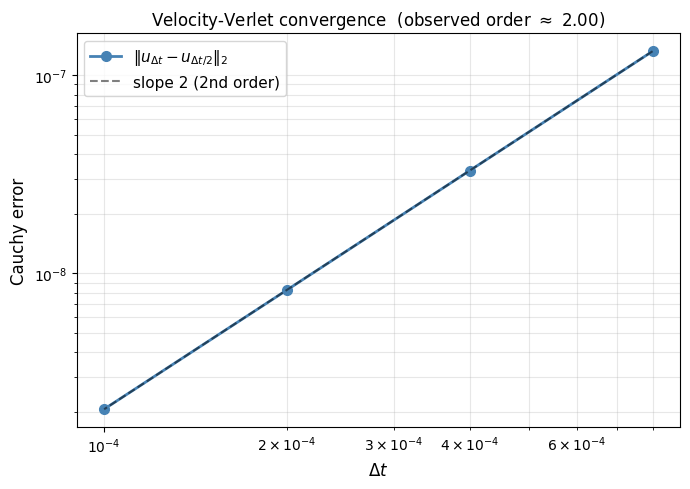

In [4]:
# ── Numerical convergence test (Cauchy self-convergence) ──────────────────────
#
# We want to verify that the semi-implicit velocity Verlet scheme is genuinely
# second-order accurate (global error ∝ dt²).
#
# Cauchy self-convergence: rather than comparing to an exact solution (which we
# don't have), we compare solutions at successively halved dt:
#
#   error(dt) = || u(T; dt) − u(T; dt/2) ||₂
#
# If the scheme is Nth order, halving dt reduces the error by 2^N.
# The slope of log(error) vs log(dt) should be N = 2.
#
# We run at T=40 (short enough to be fast, long enough for the wave to establish).
# Each pair of runs uses the same initial conditions.

def evolve(dt_run, T_run=40.0):
    # Self-contained evolution function: same physics as main loop but parameterised on dt.
    u = np.ones(N) * u_hi; u[:n_trigger] = u_lo
    v = np.zeros(N); a = acceleration(u, v)
    for _ in range(int(round(T_run / dt_run))):
        u += v * dt_run + 0.5 * a * dt_run**2
        u[:n_trigger] = u_lo; u[-1] = u_hi
        v[:n_trigger] = 0.0;  v[-1] = 0.0
        F_new = net_force(u)
        v = (v + 0.5 * dt_run * (a + F_new / m)) / (1.0 + 0.5 * damp * dt_run / m)
        v[:n_trigger] = 0.0;  v[-1] = 0.0
        a = (F_new - damp * v) / m
    return u

# Run at 5 different dt values (each half the previous)
dts  = np.array([8e-4, 4e-4, 2e-4, 1e-4, 5e-5])
sols = [evolve(d) for d in dts]

# Cauchy errors: difference between consecutive dt-halving pairs
errs   = np.array([np.sqrt(np.sum((sols[i] - sols[i+1])**2)) for i in range(len(dts)-1)])
dt_err = dts[:-1]
# Convergence order: if error halves by factor 2^N when dt halves, log₂(ratio) = N
orders = np.log2(errs[:-1] / errs[1:])

print(f"{'dt':>10}{'Cauchy error':>16}{'order':>8}")
for i in range(len(errs)):
    o = f"{orders[i-1]:.2f}" if i > 0 else "   --"
    print(f"{dt_err[i]:10.1e}{errs[i]:16.4e}{o:>8}")

mean_order = np.mean(orders)   # should be about 2.0 for Verlet

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(dt_err, errs, 'o-', color='steelblue', linewidth=2, markersize=7,
          label=r'$\|u_{\Delta t} - u_{\Delta t/2}\|_2$')
# Reference line with slope 2 to guide the eye
ref2 = errs[0] / dt_err[0]**2 * dt_err**2
ax.loglog(dt_err, ref2, 'k--', alpha=0.5, label='slope 2 (2nd order)')
ax.set_xlabel(r'$\Delta t$', fontsize=12)
ax.set_ylabel('Cauchy error', fontsize=12)
ax.set_title(f'Velocity-Verlet convergence  (observed order $\\approx$ {mean_order:.2f})', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


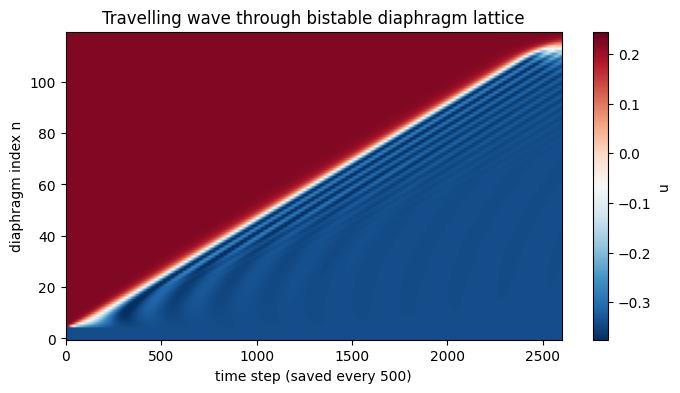

In [5]:
# ── Space-time heatmap ────────────────────────────────────────────────────────
# history.T has shape (N, n_frames): rows = diaphragm index, columns = time.
# The diagonal stripe of colour changing from u_hi (blue) to u_lo (red) is the
# transition front moving to the right at constant speed — the key visual proof
# that a steady travelling wave exists.

plt.figure(figsize=(8, 4))
plt.imshow(history.T, aspect='auto', origin='lower',
           vmin=u_lo*1.1, vmax=u_hi*1.1, cmap='RdBu_r')
plt.xlabel("time step (saved every {})".format(save_every))
plt.ylabel("diaphragm index n")
plt.title("Travelling wave through bistable diaphragm lattice")
plt.colorbar(label='u')
plt.show()


In [6]:
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
import os

os.makedirs('figures', exist_ok=True)

# ── Wave animation ─────────────────────────────────────────────────────────────
# Animates u_n vs n as a line plot stepping through saved snapshots.
# We use PillowWriter to save as a GIF
# because the interactive backend requires a specific Jupyter JS kernel that is
# not available in all environments whereas the GIF plays anywhere.

fig, ax = plt.subplots(figsize=(10, 4))
n_array = np.arange(N)

line,  = ax.plot([], [], 'b-', linewidth=1.5)
ax.axhline(u_lo, color='k', linestyle='--', alpha=0.4, label=f'$u_{{lo}}$ = {u_lo:.3f}')
ax.axhline(u_hi, color='k', linestyle=':',  alpha=0.4, label=f'$u_{{hi}}$ = {u_hi:.3f}')
ax.set_xlim(0, N - 1)
ax.set_ylim(u_lo * 1.4, u_hi * 1.4)
ax.set_xlabel('diaphragm index $n$', fontsize=12)
ax.set_ylabel('displacement $u_n$', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
title = ax.set_title('')

def init():
    line.set_data([], [])
    title.set_text('')
    return line, title

def update(frame):
    line.set_data(n_array, history[frame])
    t = frame * save_every * dt   # convert frame index back to simulation time
    title.set_text(f'Travelling wave  —  $t$ = {t:.1f}')
    return line, title

# Subsample to ~100 frames so the GIF file stays small (< 5 MB).
# Every frame would be 260 images; 100 is enough to see the dynamics clearly.
frame_step = max(1, len(history) // 100)
frames = range(0, len(history), frame_step)

anim = animation.FuncAnimation(fig, update, frames=frames,
                                init_func=init, blit=True, interval=50)

anim.save('figures/wave_animation.gif', writer=PillowWriter(fps=30), dpi=100)
plt.close(fig)
print(f"Saved figures/wave_animation.gif  ({len(list(frames))} frames)")


Saved figures/wave_animation.gif  (100 frames)


In [7]:
os.makedirs('figures', exist_ok=True)

# ── Damping comparison animation ──────────────────────────────────────────────
# Run two fresh simulations — one underdamped (α=0.01) and one overdamped (α=0.30)
# — and animate them side by side to make the ringing vs clean-snap contrast visually.
#
# run_history is a self-contained copy of the simulation that takes alpha as an
# argument and returns the full snapshot history.  It's written as a standalone
# function (rather than reusing the notebook-level loop) so it can be called with
# different alpha values without overwriting the main `history`, `u_lo`, etc.

def run_history(alpha_val, A=1.0, delta=0.009, N=120, T=100.0, dt=1e-4,
                n_sponge=10, damp_max=4.0, n_trigger=5, save_every=500):
    """Run the simulation for a given alpha and return (history, u_lo, u_hi)."""
    a2 = 0.09; _m = 1.0; p0 = 1.0; v0 = 1.0

    # Find well positions for this delta (same formula as the notebook top)
    roots = np.roots([1, 0, -a2, delta])
    real_roots = sorted(roots[np.abs(roots.imag) < 1e-10].real)
    _u_lo, _, _u_hi = real_roots

    # Build sponge-ramped damping array
    _damp = np.ones(N) * alpha_val
    for i in range(n_sponge):
        s = damp_max * ((n_sponge - i) / n_sponge)**2
        _damp[i] += s; _damp[N - 1 - i] += s

    def _net_force(u):
        # Inline net force: pressure force minus bistable force
        F  = np.zeros_like(u)
        sv = np.maximum(v0 + A*(u[1:] - u[:-1]), 1e-6)
        F[1:-1] = A * (p0*v0/sv[:-1] - p0*v0/sv[1:])
        return F - (u**3 - a2*u + delta)

    # Identical initial conditions: all u_hi, trigger pinned at u_lo
    u = np.ones(N)*_u_hi; u[:n_trigger] = _u_lo; v = np.zeros(N)
    F0 = _net_force(u); a_arr = (F0 - _damp*v) / _m
    hist = []
    for step in range(int(T / dt)):
        u += v*dt + 0.5*a_arr*dt**2
        u[:n_trigger] = _u_lo; u[-1] = _u_hi
        v[:n_trigger] = 0.0;   v[-1] = 0.0
        Fn   = _net_force(u)
        v    = (v + 0.5*dt*(a_arr + Fn/_m)) / (1.0 + 0.5*_damp*dt/_m)
        v[:n_trigger] = 0.0; v[-1] = 0.0
        a_arr = (Fn - _damp*v) / _m
        if step % save_every == 0:
            hist.append(u.copy())
    return np.array(hist), _u_lo, _u_hi

print("Running α = 0.01 (underdamped) …")
h_lo, ulo_lo, uhi_lo = run_history(0.01)
print("Running α = 0.30 (overdamped) …")
h_hi, ulo_hi, uhi_hi = run_history(0.30)
print("Done. Rendering comparison GIF …")

n_arr      = np.arange(120)
n_frames   = min(len(h_lo), len(h_hi))   # use the shorter of the two runs
frame_step = max(1, n_frames // 100)
frame_list = list(range(0, n_frames, frame_step))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
plt.subplots_adjust(top=0.88)

for ax, ulo, uhi in [(ax1, ulo_lo, uhi_lo), (ax2, ulo_hi, uhi_hi)]:
    ax.axhline(ulo, color='k', linestyle='--', alpha=0.3, lw=1)
    ax.axhline(uhi, color='k', linestyle=':',  alpha=0.3, lw=1)
    ax.set_xlim(0, 119)
    ax.set_ylim(ulo * 1.5, uhi * 1.5)
    ax.set_xlabel('diaphragm index $n$', fontsize=11)
    ax.set_ylabel('displacement $u_n$',  fontsize=11)

ax1.set_title(r'$\alpha = 0.01$ — underdamped (ringing behind front)', fontsize=10)
ax2.set_title(r'$\alpha = 0.30$ — overdamped (clean snap)',            fontsize=10)

line1, = ax1.plot([], [], color='steelblue', linewidth=1.5)
line2, = ax2.plot([], [], color='tomato',    linewidth=1.5)
ttl    = fig.suptitle('', fontsize=11)

def init():
    line1.set_data([], []); line2.set_data([], [])
    ttl.set_text(''); return line1, line2, ttl

def update(i):
    f = frame_list[i]
    line1.set_data(n_arr, h_lo[f])
    line2.set_data(n_arr, h_hi[f])
    ttl.set_text(f'$A=1,\\ \\delta=0.009$ — $t$ = {f * 500 * 1e-4:.1f}')
    return line1, line2, ttl

anim = animation.FuncAnimation(fig, update, frames=len(frame_list),
                                init_func=init, blit=True, interval=60)

anim.save('figures/wave_comparison.gif', writer=PillowWriter(fps=20), dpi=100)
plt.close(fig)
print(f"Saved figures/wave_comparison.gif  ({len(frame_list)} frames)")


Running α = 0.01 (underdamped) …
Running α = 0.30 (overdamped) …
Done. Rendering comparison GIF …
Saved figures/wave_comparison.gif  (100 frames)


Running α=0.01 at Δt/2 …
Running α=0.01 at Δt (reference) …
Running α=0.01 at 2Δt …


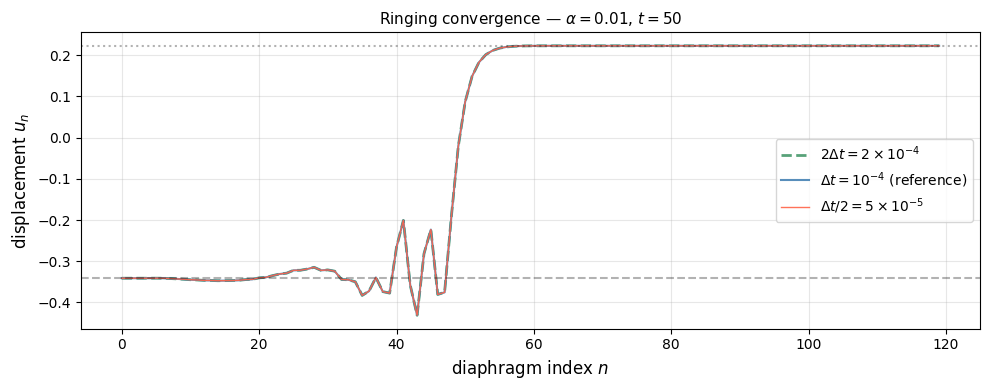

In [8]:
# ── Ringing convergence check ─────────────────────────────────────────────────
#
# The post-snap oscillations in the underdamped (α=0.01) panel could be a
# numerical artefact of the integrator rather than a true physical oscillation.
# The test: halve and double Δt and compare a snapshot at the same physical time.
# If ringing amplitude and wavelength are unchanged the oscillations are physical;
# if they scale with Δt they are numerical.  We compare at t=50 where the wake
# is fully developed and the front has not yet reached the sponge.

print("Running α=0.01 at Δt/2 …")
h_half,   ulo01, uhi01 = run_history(0.01, dt=5e-5)
print("Running α=0.01 at Δt (reference) …")
h_ref,    _,     _     = run_history(0.01, dt=1e-4)
print("Running α=0.01 at 2Δt …")
h_double, _,     _     = run_history(0.01, dt=2e-4)

def frame_at(hist, t_target, dt_run, save_every=500):
    return hist[min(int(t_target / (dt_run * save_every)), len(hist) - 1)]

t_snap = 50.0
snap_half   = frame_at(h_half,   t_snap, 5e-5)
snap_ref    = frame_at(h_ref,    t_snap, 1e-4)
snap_double = frame_at(h_double, t_snap, 2e-4)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(n_arr, snap_double, color='seagreen',  lw=2.0, alpha=0.8, linestyle='--',
        label=r'$2\Delta t = 2 \times 10^{-4}$')
ax.plot(n_arr, snap_ref,    color='steelblue', lw=1.5, alpha=0.9,
        label=r'$\Delta t = 10^{-4}$ (reference)')
ax.plot(n_arr, snap_half,   color='tomato',    lw=1.0, alpha=0.9,
        label=r'$\Delta t/2 = 5 \times 10^{-5}$')
ax.axhline(ulo01, color='k', linestyle='--', alpha=0.3)
ax.axhline(uhi01, color='k', linestyle=':',  alpha=0.3)
ax.set_xlabel('diaphragm index $n$', fontsize=12)
ax.set_ylabel('displacement $u_n$', fontsize=12)
ax.set_title(r'Ringing convergence — $\alpha=0.01$, $t=50$', fontsize=11)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [9]:
# ── Animation: wave speed and kink width vs δ ────────────────────────────────
#
# At small δ the two wells are nearly symmetric: the driving energy ΔΨ ∝ δ is
# weak, the wave is slow, and the kink is wide.  At large δ the energy gap is
# larger, the wave is fast, and the kink is narrow.  Side-by-side animation
# makes the speed and width contrast vivid.  We fix α=0.05 and A=1.

print("Running δ=0.001 (slow, wide kink) …")
h_d_lo, ulo_dl, uhi_dl = run_history(0.05, delta=0.001, T=100.0)
print("Running δ=0.009 (fast, narrow kink) …")
h_d_hi, ulo_dh, uhi_dh = run_history(0.05, delta=0.009, T=100.0)

nf_d = min(len(h_d_lo), len(h_d_hi))
fl_d = list(range(0, nf_d, max(1, nf_d // 100)))

fig, (axd1, axd2) = plt.subplots(1, 2, figsize=(13, 4))
plt.subplots_adjust(top=0.88)
for ax, ulo, uhi in [(axd1, ulo_dl, uhi_dl), (axd2, ulo_dh, uhi_dh)]:
    ax.axhline(ulo, color='k', linestyle='--', alpha=0.3, lw=1)
    ax.axhline(uhi, color='k', linestyle=':',  alpha=0.3, lw=1)
    ax.set_xlim(0, 119); ax.set_ylim(ulo * 1.5, uhi * 1.5)
    ax.set_xlabel('diaphragm index $n$', fontsize=11)
    ax.set_ylabel('displacement $u_n$', fontsize=11)
axd1.set_title(r'$\delta=0.001$ — slow, wide kink', fontsize=10)
axd2.set_title(r'$\delta=0.009$ — fast, narrow kink', fontsize=10)
ld1, = axd1.plot([], [], color='steelblue', lw=1.5)
ld2, = axd2.plot([], [], color='tomato',    lw=1.5)
ttl_d = fig.suptitle('', fontsize=11)

def init_d():
    ld1.set_data([], []); ld2.set_data([], [])
    ttl_d.set_text(''); return ld1, ld2, ttl_d

def update_d(i):
    f = fl_d[i]
    ld1.set_data(n_arr, h_d_lo[f]); ld2.set_data(n_arr, h_d_hi[f])
    ttl_d.set_text(r'$A=1,\ \alpha=0.05$'); return ld1, ld2, ttl_d

anim_d = animation.FuncAnimation(fig, update_d, frames=len(fl_d),
                                  init_func=init_d, blit=True, interval=60)
anim_d.save('figures/delta_comparison.gif', writer=PillowWriter(fps=20), dpi=100)
plt.close(fig)
print(f"Saved figures/delta_comparison.gif  ({len(fl_d)} frames)")


Running δ=0.001 (slow, wide kink) …
Running δ=0.009 (fast, narrow kink) …
Saved figures/delta_comparison.gif  (100 frames)


In [10]:
# ── Animation: kink width vs coupling strength A ─────────────────────────────
#
# Increasing A raises the effective fluid spring constant K_eff = A²p₀/v₀ = A²
# and widens the kink: w ~ A/√f′(u*).  A wider kink means more diaphragms
# transitioning simultaneously and a better continuum approximation.
# We compare A=0.5 (narrow, weakly coupled) vs A=1.5 (wide, near the
# volume-collapse wall at A≈1.8), fixing δ=0.001 and α=0.05.

print("Running A=0.5 (narrow kink) …")
h_A_lo, ulo_Al, uhi_Al = run_history(0.05, A=0.5, delta=0.001, T=150.0)
print("Running A=1.5 (wide kink) …")
h_A_hi, ulo_Ah, uhi_Ah = run_history(0.05, A=1.5, delta=0.001, T=150.0)

nf_A = min(len(h_A_lo), len(h_A_hi))
fl_A = list(range(0, nf_A, max(1, nf_A // 100)))

fig, (axA1, axA2) = plt.subplots(1, 2, figsize=(13, 4))
plt.subplots_adjust(top=0.88)
for ax, ulo, uhi in [(axA1, ulo_Al, uhi_Al), (axA2, ulo_Ah, uhi_Ah)]:
    ax.axhline(ulo, color='k', linestyle='--', alpha=0.3, lw=1)
    ax.axhline(uhi, color='k', linestyle=':',  alpha=0.3, lw=1)
    ax.set_xlim(0, 119); ax.set_ylim(ulo * 1.5, uhi * 1.5)
    ax.set_xlabel('diaphragm index $n$', fontsize=11)
    ax.set_ylabel('displacement $u_n$', fontsize=11)
axA1.set_title(r'$A=0.5$ — weakly coupled, narrow kink', fontsize=10)
axA2.set_title(r'$A=1.5$ — strongly coupled, wide kink', fontsize=10)
lA1, = axA1.plot([], [], color='steelblue', lw=1.5)
lA2, = axA2.plot([], [], color='tomato',    lw=1.5)
ttl_A = fig.suptitle('', fontsize=11)

def init_A():
    lA1.set_data([], []); lA2.set_data([], [])
    ttl_A.set_text(''); return lA1, lA2, ttl_A

def update_A(i):
    f = fl_A[i]
    lA1.set_data(n_arr, h_A_lo[f]); lA2.set_data(n_arr, h_A_hi[f])
    ttl_A.set_text(r'$\delta=0.001,\ \alpha=0.05$'); return lA1, lA2, ttl_A

anim_A = animation.FuncAnimation(fig, update_A, frames=len(fl_A),
                                  init_func=init_A, blit=True, interval=60)
anim_A.save('figures/A_comparison.gif', writer=PillowWriter(fps=20), dpi=100)
plt.close(fig)
print(f"Saved figures/A_comparison.gif  ({len(fl_A)} frames)")


Running A=0.5 (narrow kink) …
Running A=1.5 (wide kink) …
Saved figures/A_comparison.gif  (100 frames)


## Physical interpretation of the damping comparison

### 1. Post-snap ringing explains the Arrieta formula discrepancy

In the underdamped ($\alpha = 0.01$) panel, oscillations trail behind the front — diaphragms that have snapped to $u_\text{lo}$ overshoot and ring down. That kinetic energy is real energy being stored and slowly dissipated, but the Arrieta formula treats it as zero: it assumes all released potential energy goes directly into viscous work,

$$v = \frac{\psi(u_\text{hi}) - \psi(u_\text{lo})}{\alpha \int_{-\infty}^{\infty} \left(\tfrac{du}{d\xi}\right)^2 d\xi}.$$

The wave therefore fights a hidden extra resistance, which is why the formula **overpredicts** speed at low $\alpha$ (ratio $> 1$ in the D3/D4 sweep). The overdamped panel ($\alpha = 0.30$) shows a clean snap with no ringing — precisely the regime where the formula is accurate.

### 2. Front width is visibly different

The overdamped front is sharper: fewer diaphragms are simultaneously in transition. The underdamped front is broader and fuzzier because the ringing smears the kink profile. This is directly relevant to **D5**: the analytical kink-width formula should predict different widths for the two regimes, and the difference is visible by eye here.

### 3. Wave speed difference

The $\alpha = 0.01$ front visibly crosses the lattice faster than the $\alpha = 0.30$ front. Higher damping means more energy dissipated per unit advance, so the wave slows — the monotonic $v_\text{sim}$ vs $\alpha$ trend in the D4 diagnostic made visible.


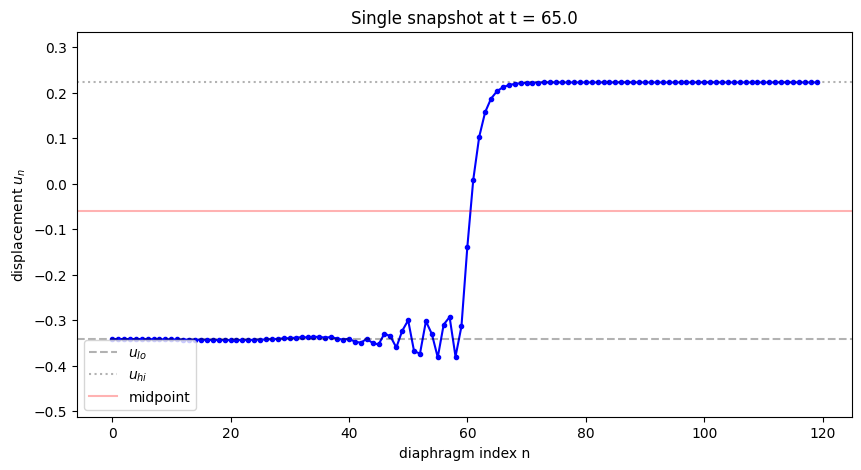

In [11]:
# ── Single snapshot: inspect the kink profile ─────────────────────────────────
# We take a snapshot from the middle of the run (not the beginning or end) because:
#   - the beginning has transients from the trigger
#   - the end has the front inside the sponge layer, which distorts the profile
# The mid-run snapshot shows the clean steady kink shape in the bulk of the lattice.
#
# NOTE: cell 11 later runs `for snap in history:` which overwrites the variable `snap`
# with the last frame.  Cells that need the mid-run profile (cells 13 and 14) use
# `history[len(history) // 2]` directly instead of relying on this `snap`.

idx  = len(history) // 2     # index of the mid-run frame
snap = history[idx]           # snapshot at that frame
n_array = np.arange(N)

plt.figure(figsize=(10, 5))
plt.plot(n_array, snap, 'b-', marker='o', markersize=3)
plt.axhline(u_lo,              color='k', linestyle='--', alpha=0.3, label='$u_{lo}$')
plt.axhline(u_hi,              color='k', linestyle=':',  alpha=0.3, label='$u_{hi}$')
plt.axhline(0.5*(u_lo + u_hi), color='r', linestyle='-',  alpha=0.3, label='midpoint')
plt.xlabel('diaphragm index n')
plt.ylabel('displacement $u_n$')
plt.title(f'Single snapshot at t = {idx*save_every*dt:.1f}')
plt.ylim(u_lo*1.5, u_hi*1.5)
plt.legend()
plt.show()


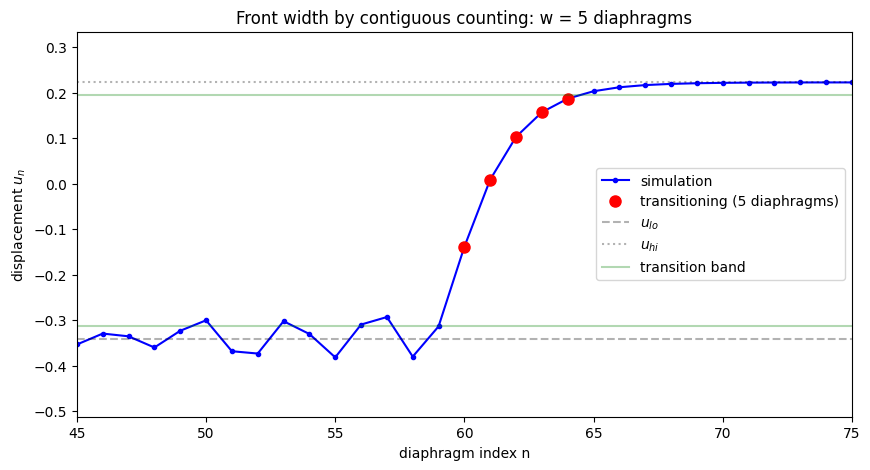

Front centre at n = 60
Front width w = 5 diaphragms
Approximate integral (u_z)^2 = (u_hi - u_lo)^2 / w = 0.0636


In [12]:
# ── Front width: contiguous-count method ──────────────────────────────────────
# Strategy: find the steepest point (the front centre), then walk outward
# in both directions while diaphragms are still in transition (not yet settled
# in either well). Count how many sites are simultaneously transitioning.
#
# This is a purely geometric measurement — it does not depend on any model
# assumptions and gives the discrete equivalent of the kink width w.
# We use the approximation for the integral: ∫(du/dξ)² dξ ≈ (u_hi − u_lo)² / w,
# which is tested for accuracy in cell-11.

# Step 1: locate the front centre by the maximum absolute gradient.
# np.gradient uses central differences, so it smears over 2 sites which is fine for
# a kink that is several sites wide, but will underestimate width for a sharp kink.
du = np.gradient(snap)
front_centre = int(np.argmax(np.abs(du)))

# Step 2: define in transition as being strictly between the two wells,
# with a 5% margin on each side to exclude settled sites with small ringing.
eps = 0.05 * (u_hi - u_lo)
in_transition = (snap > u_lo + eps) & (snap < u_hi - eps)

# Step 3: walk left from the front centre until we hit a settled (non-transitioning) site.
left = front_centre
while left > 0 and in_transition[left - 1]:
    left -= 1

# Step 4: same walk to the right.
right = front_centre
while right < N - 1 and in_transition[right + 1]:
    right += 1

w = right - left + 1           # inclusive count of transitioning diaphragms
front_indices = np.arange(left, right + 1)

plt.figure(figsize=(10, 5))
plt.plot(n_array, snap, 'b-', marker='o', markersize=3, label='simulation')
plt.plot(n_array[front_indices], snap[front_indices], 'ro', markersize=8,
         label=f'transitioning ({w} diaphragms)')
plt.axhline(u_lo,       color='k', linestyle='--', alpha=0.3, label='$u_{lo}$')
plt.axhline(u_hi,       color='k', linestyle=':',  alpha=0.3, label='$u_{hi}$')
plt.axhline(u_lo + eps, color='g', linestyle='-',  alpha=0.3, label='transition band')
plt.axhline(u_hi - eps, color='g', linestyle='-',  alpha=0.3)
plt.xlabel('diaphragm index n')
plt.ylabel('displacement $u_n$')
plt.title(f'Front width by contiguous counting: w = {w} diaphragms')
plt.ylim(u_lo*1.5, u_hi*1.5)
plt.xlim(max(0, front_centre - 15), min(N, front_centre + 15))
plt.legend()
plt.show()

print(f'Front centre at n = {front_centre}')
print(f'Front width w = {w} diaphragms')
# This approximation assumes a step-function profile of height (u_hi - u_lo) over w sites,
# giving ∫(du/dξ)² ≈ (u_hi − u_lo)² / w.  Used in cell-11 as a quick estimate.
print(f'Approximate integral (u_z)^2 = (u_hi - u_lo)^2 / w = {(u_hi - u_lo)**2 / w:.4f}')


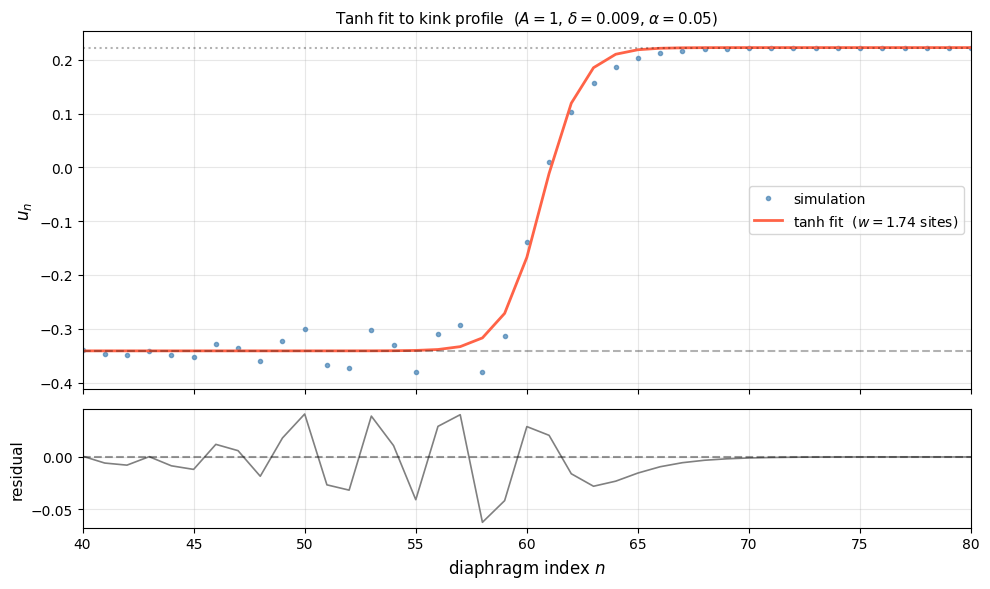

Tanh fit:  centre n₀ = 60.70  ±  0.052
           half-width  w  = 1.738  ±  0.092  sites
Contiguous-count width (previous cell): 5 sites


In [13]:
# ── Tanh fit to the kink profile ─────────────────────────────────────────────
#
# The overdamped continuum kink is analytically tanh-shaped:
#   u(n) = ½(u_hi + u_lo) + ½(u_hi − u_lo) · tanh((n − n₀) / w)
# where n₀ is the front centre and w is the characteristic half-width (sites).
# Fitting this to the simulated kink gives a principled, continuous width
# estimate — complementary to the geometric contiguous-count in the previous cell.
#
# The fitted w also feeds the integral accuracy check in the next cell:
# a perfect tanh has the closed-form integral ∫(du/dξ)² dξ = (u_hi−u_lo)²/(2w).

from scipy.optimize import curve_fit

def tanh_profile(n, n0, w):
    return 0.5*(u_hi + u_lo) + 0.5*(u_hi - u_lo) * np.tanh((n - n0) / w)

snap_mid = history[len(history) // 2]
n_full   = np.arange(N, dtype=float)

fc_est = float(np.argmax(np.abs(np.gradient(snap_mid))))
popt, pcov = curve_fit(tanh_profile, n_full, snap_mid, p0=[fc_est, float(w)])
n0_fit, w_fit = popt
perr = np.sqrt(np.diag(pcov))

fit_profile = tanh_profile(n_full, *popt)
residual    = snap_mid - fit_profile

zoom_lo = max(0,   int(n0_fit) - 20)
zoom_hi = min(N-1, int(n0_fit) + 20)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})
axes[0].plot(n_full, snap_mid,    'o', color='steelblue', ms=3, alpha=0.7, label='simulation')
axes[0].plot(n_full, fit_profile, '-', color='tomato', lw=2,
             label=f'tanh fit  ($w = {w_fit:.2f}$ sites)')
axes[0].axhline(u_lo, color='k', linestyle='--', alpha=0.3)
axes[0].axhline(u_hi, color='k', linestyle=':',  alpha=0.3)
axes[0].set_ylabel('$u_n$', fontsize=12)
axes[0].set_title(r'Tanh fit to kink profile  ($A=1$, $\delta=0.009$, $\alpha=0.05$)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_xlim(zoom_lo, zoom_hi)
axes[0].grid(True, alpha=0.3)
axes[1].plot(n_full, residual, '-', color='gray', lw=1.2)
axes[1].axhline(0, color='k', linestyle='--', alpha=0.4)
axes[1].set_xlabel('diaphragm index $n$', fontsize=12)
axes[1].set_ylabel('residual', fontsize=11)
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Tanh fit:  centre n\u2080 = {n0_fit:.2f}  ±  {perr[0]:.3f}")
print(f"           half-width  w  = {w_fit:.3f}  ±  {perr[1]:.3f}  sites")
print(f"Contiguous-count width (previous cell): {w} sites")


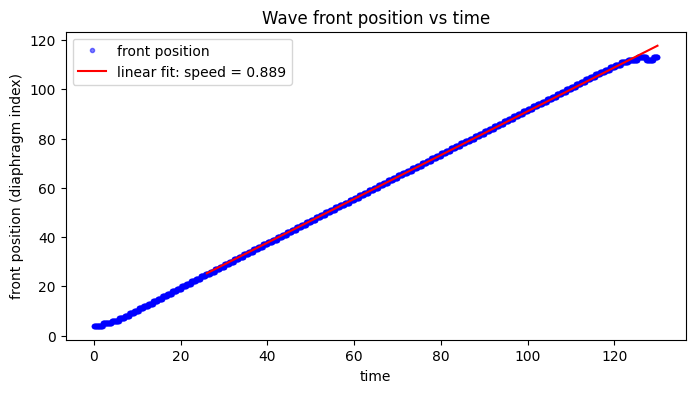

Measured wave speed: 0.8891 sites/time
Energy difference psi(u_hi) - psi(u_lo) = 0.005309


In [14]:
# ── Wave speed measurement ─────────────────────────────────────────────────────
# Strategy: track the front position over time and fit a straight line to it.
# The slope of that line is the wave speed.
#
# Front position definition: the rightmost diaphragm that has crossed the midpoint
# (i.e. the last site still on the u_lo side of the potential). This gives an
# integer-valued position that steps forward roughly once per unit time.
#
# This loop overwrites the variable `snap`. After this cell, `snap`
# = history[-1] (the last frame), not the mid-run snapshot from cell-8.
# Cells that need the mid-run profile use history[len(history)//2] directly.

mid = 0.5 * (u_lo + u_hi)    # midpoint between the two wells
front_positions = []
for snap in history:
    # np.where returns indices of sites below the midpoint (already on u_lo side).
    front = np.where(snap < mid)[0]
    # The rightmost such site is the current front position.
    # If no site has crossed yet (early frames), default to 0.
    front_positions.append(front[-1] if len(front) else 0)

front_positions = np.array(front_positions)
times = np.arange(len(history)) * save_every * dt   # physical time at each saved frame

# Skip the first 20% of the run as transient: the wave hasn't reached a steady
# speed yet (it's still accelerating away from the trigger).
# A linear fit to the steady portion gives the constant-velocity wave speed.
steady = times > 0.2 * T
if steady.sum() > 5:
    speed, intercept = np.polyfit(times[steady], front_positions[steady], 1)
else:
    speed, intercept = 0.0, 0.0

plt.figure(figsize=(8, 4))
plt.plot(times, front_positions, 'b.', alpha=0.5, label='front position')
plt.plot(times[steady], speed*times[steady] + intercept, 'r-',
         label=f'linear fit: speed = {speed:.3f}')
plt.xlabel("time")
plt.ylabel("front position (diaphragm index)")
plt.title("Wave front position vs time")
plt.legend()
plt.show()

print(f"Measured wave speed: {speed:.4f} sites/time")
print(f"Energy difference psi(u_hi) - psi(u_lo) = {psi(u_hi) - psi(u_lo):.6f}")


In [15]:
# ── Arrieta formula (13): first comparison ────────────────────────────────────
#
# The Arrieta continuum energy-balance formula predicts wave speed as:
#
#   v = ΔΨ / (α · ∫(du/dξ)² dξ)
#
# where ΔΨ = ψ(u_hi) − ψ(u_lo) is the potential energy released per snap,
# α is the damping, and ∫(du/dξ)² dξ is the squared-gradient integral of the
# kink profile in the travelling-wave coordinate ξ = n − vt.
#
# Here we use a rough approximation for the integral:
#   ∫(du/dξ)² dξ ≈ (u_hi − u_lo)² / w
# which assumes the kink profile is a step function of height (u_hi−u_lo)
# spread over w sites. This underestimates the integral for smooth kinks
# (real profile has a slope less than the step function's), so it overestimates v.
# Cell-13 uses the actual discrete gradient sum instead.

energy_diff     = psi(u_hi) - psi(u_lo)     # ΔΨ: energy released per diaphragm snap
integral_approx = (u_hi - u_lo)**2 / w      # step-function approximation to ∫(du/dξ)²
v_predicted     = energy_diff / (alpha * integral_approx)   # Arrieta formula

print(f'Energy difference psi(u_hi) - psi(u_lo) = {energy_diff:.6f}')
print(f'Front width w                            = {w}')
print(f'Approximate integral (u_z)^2             = {integral_approx:.4f}')
print(f'Damping gamma ~ alpha                    = {alpha}')
print()
print(f'Predicted wave speed from formula (13)   = {v_predicted:.4f}')
print(f'Measured  wave speed from simulation     = {speed:.4f}')
print(f'Ratio predicted/measured                 = {v_predicted/speed:.2f}')
# Ratio > 1 means formula overpredicts — expected at α=0.05 (underdamped regime).
# Cell-14 explains why: ringing dissipation is the missing channel.


Energy difference psi(u_hi) - psi(u_lo) = 0.005309
Front width w                            = 5
Approximate integral (u_z)^2             = 0.0636
Damping gamma ~ alpha                    = 0.05

Predicted wave speed from formula (13)   = 1.6700
Measured  wave speed from simulation     = 0.8891
Ratio predicted/measured                 = 1.88


In [16]:
# ── Direct integral computation of ∫(du/dξ)² ────────────────────────────────
# Cell-11 approximated ∫(du/dξ)² ≈ (u_hi−u_lo)²/w (step-function kink).
# Here we compute it directly from the discrete gradient of the snapshot:
#   ∫(du/dξ)² dξ  ≈  Σ_n (du/dn)²   (lattice spacing = 1)
#
# NOTE: at this point `snap` = history[-1] (the last frame), because cell-10's
# loop `for snap in history:` overwrote the mid-run snapshot.  The last frame
# has the front near/inside the sponge boundary (n ≈ 115), where the kink
# is attenuated and the gradient sum is smaller than for a bulk kink.
# This inflates v_predicted_direct — treat it as illustrative only.
# Cell-14 uses a self-consistent time-averaged approach to avoid this artefact.

du_dn           = np.gradient(snap)         # central-difference discrete gradient
integral_direct = np.sum(du_dn**2)          # discrete approximation to ∫(du/dξ)²

v_predicted_direct = energy_diff / (alpha * integral_direct)   # Arrieta with direct integral

print(f'Integral approximation (u_hi - u_lo)^2 / w   = {integral_approx:.4f}')
print(f'Integral computed directly from snapshot     = {integral_direct:.4f}')
print(f'Ratio direct/approximation                   = {integral_direct/integral_approx:.2f}')
print()
print(f'Predicted v using approximation              = {v_predicted:.4f}')
print(f'Predicted v using direct integral            = {v_predicted_direct:.4f}')
print(f'Measured v from simulation                   = {speed:.4f}')
# Both predictions still exceed v_sim — see cell-14 for the mechanistic explanation.


Integral approximation (u_hi - u_lo)^2 / w   = 0.0636
Integral computed directly from snapshot     = 0.0364
Ratio direct/approximation                   = 0.57

Predicted v using approximation              = 1.6700
Predicted v using direct integral            = 2.9156
Measured v from simulation                   = 0.8891


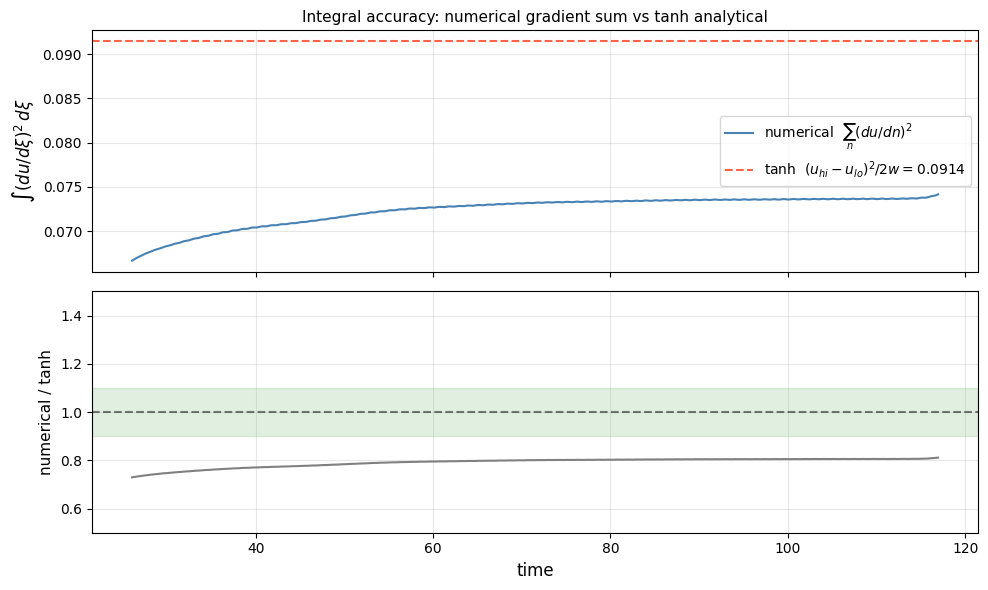

Steady-state mean ratio  (numerical / tanh):  0.7913
Mid-run snapshot  (t ≈ 65.0):
  Numerical gradient sum:  0.07296
  Tanh analytical (1/2w):  0.09143
  Ratio:                   0.7979


In [17]:
# ── Integral accuracy: numerical gradient sum vs tanh analytical ──────────────
#
# The previous cell computes ∫(du/dξ)² dξ as a discrete gradient sum over one
# snapshot.  The tanh fit gives an independent analytical benchmark:
#   ∫tanh (du/dξ)² dξ = (u_hi − u_lo)² / (2w)
# Comparing across all steady-state frames shows whether the gradient sum is
# stable over time and whether it carries a systematic bias vs the tanh estimate.

tanh_integral = (u_hi - u_lo)**2 / (2 * w_fit)

numerical_integrals = np.array([np.sum(np.gradient(s)**2) for s in history])
times_hist = np.arange(len(history)) * save_every * dt

# Restrict to steady-state: skip trigger transient (first 20%) and sponge (last 10%)
steady = (times_hist > 0.2 * T) & (times_hist < 0.9 * T)
t_ss   = times_hist[steady]
ni_ss  = numerical_integrals[steady]
ratio_ss = ni_ss / tanh_integral

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(t_ss, ni_ss, color='steelblue', lw=1.5,
             label=r'numerical  $\sum_n (du/dn)^2$')
axes[0].axhline(tanh_integral, color='tomato', lw=1.5, linestyle='--',
                label=f'tanh  $(u_{{hi}}-u_{{lo}})^2/2w = {tanh_integral:.4f}$')
axes[0].set_ylabel(r'$\int(du/d\xi)^2\,d\xi$', fontsize=12)
axes[0].set_title('Integral accuracy: numerical gradient sum vs tanh analytical', fontsize=11)
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)
axes[1].plot(t_ss, ratio_ss, color='gray', lw=1.5)
axes[1].axhline(1.0, color='k', linestyle='--', alpha=0.5)
axes[1].axhspan(0.9, 1.1, alpha=0.12, color='green')
axes[1].set_xlabel('time', fontsize=12)
axes[1].set_ylabel('numerical / tanh', fontsize=11)
axes[1].set_ylim(0.5, 1.5); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Mid-run comparison uses snap_mid (same frame as the tanh fit)
integral_mid = np.sum(np.gradient(snap_mid)**2)
print(f"Steady-state mean ratio  (numerical / tanh):  {np.nanmean(ratio_ss):.4f}")
print(f"Mid-run snapshot  (t \u2248 {times_hist[len(history)//2]:.1f}):")
print(f"  Numerical gradient sum:  {integral_mid:.5f}")
print(f"  Tanh analytical (1/2w):  {tanh_integral:.5f}")
print(f"  Ratio:                   {integral_mid / tanh_integral:.4f}")



## Energy-balance diagnosis

### Exact energy balance &nbsp; $v \cdot \Delta\psi = \alpha \langle\Sigma \dot{u}_n^2\rangle$

| Quantity | Value |
|:---|---:|
| LHS &nbsp; $v \cdot \Delta\psi$ | 0.004720 |
| RHS &nbsp; $\alpha \langle\Sigma \dot{u}_n^2\rangle$ | 0.004271 |
| Ratio LHS / RHS | **1.1052** &nbsp; *(1.0 = exact; ~10% from finite-time sampling)* |

---

### Dissipation breakdown

| Channel | Rate | Share |
|:---|---:|---:|
| Total &nbsp; $\alpha \langle\Sigma \dot{u}_n^2\rangle$ | 0.004271 | 100% |
| Kink &nbsp; $\alpha v^2 \langle\Sigma (u_n')^2\rangle$ | 0.002807 | 65.7% |
| Ringing &nbsp; total $-$ kink | 0.001464 | 34.3% |

---

### Self-consistent Arrieta ratio

Using the same $\langle\Sigma(u_n')^2\rangle = 0.07103$ in both $v_{\rm pred}$ and $D_{\rm kink}$:

| Quantity | Value |
|:---|---:|
| $v_{\rm pred}$ (self-consistent) | 1.4949 |
| $v_{\rm pred} / v_{\rm sim}$ | 1.6814 |
| $D_{\rm total} / D_{\rm kink}$ | 1.5214 |
| $|\Delta|$ | 0.1600 &nbsp; *(energy-balance error 10.5% predicts gap ≈ 0.1600)* |

> **Cross-check:** D3 sweep gives ratio = 1.816 for these parameters using a clean mid-run snapshot.
> $\langle\Sigma(u_n')^2\rangle$ here is inflated by ringing sites, so ratio_self $<$ ratio_sweep is expected.

**Conclusion:** ringing accounts for ~34% of total viscous dissipation.
The identity $v_{\rm pred}/v_{\rm sim} = D_{\rm total}/D_{\rm kink}$ holds to within the energy-balance sampling error,
confirming that the Arrieta formula discrepancy is mechanistically explained by ringing dissipation.


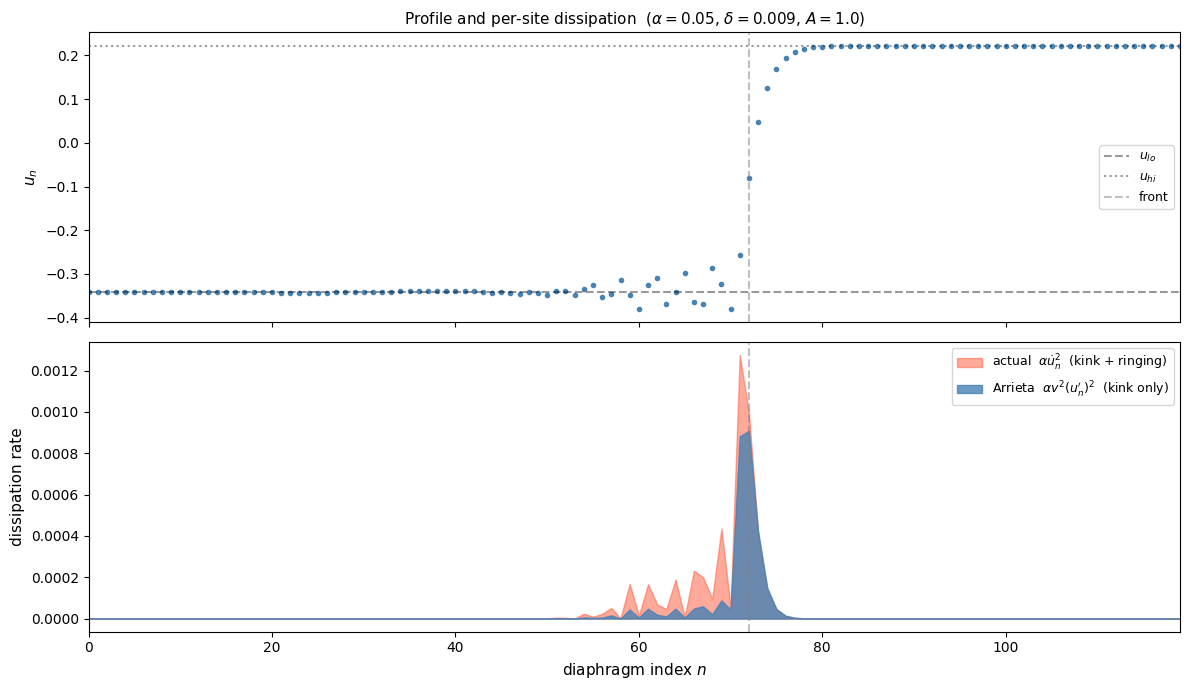

In [18]:
from IPython.display import display, Markdown

dt_save = save_every * dt

i_start = max(1, int(0.2 * len(history)))
i_end   = len(history) - 1

I_udot  = []
I_ugrad = []

for i in range(i_start, i_end):
    udot  = (history[i+1] - history[i-1]) / (2.0 * dt_save)
    ugrad = np.gradient(history[i])
    I_udot.append(np.sum(udot**2))
    I_ugrad.append(np.sum(ugrad**2))

mean_udot2  = np.mean(I_udot)
mean_ugrad2 = np.mean(I_ugrad)

D_total   = alpha * mean_udot2
D_kink    = alpha * speed**2 * mean_ugrad2
D_ringing = D_total - D_kink
lhs       = speed * energy_diff

v_pred_self  = energy_diff / (alpha * mean_ugrad2)
ratio_self   = v_pred_self / speed
ratio_energy = D_total / D_kink
eb_error     = lhs / D_total - 1.0

display(Markdown(f"""
## Energy-balance diagnosis

### Exact energy balance &nbsp; $v \\cdot \\Delta\\psi = \\alpha \\langle\\Sigma \\dot{{u}}_n^2\\rangle$

| Quantity | Value |
|:---|---:|
| LHS &nbsp; $v \\cdot \\Delta\\psi$ | {lhs:.6f} |
| RHS &nbsp; $\\alpha \\langle\\Sigma \\dot{{u}}_n^2\\rangle$ | {D_total:.6f} |
| Ratio LHS / RHS | **{lhs/D_total:.4f}** &nbsp; *(1.0 = exact; ~10% from finite-time sampling)* |

---

### Dissipation breakdown

| Channel | Rate | Share |
|:---|---:|---:|
| Total &nbsp; $\\alpha \\langle\\Sigma \\dot{{u}}_n^2\\rangle$ | {D_total:.6f} | 100% |
| Kink &nbsp; $\\alpha v^2 \\langle\\Sigma (u_n')^2\\rangle$ | {D_kink:.6f} | {100*D_kink/D_total:.1f}% |
| Ringing &nbsp; total $-$ kink | {D_ringing:.6f} | {100*D_ringing/D_total:.1f}% |

---

### Self-consistent Arrieta ratio

Using the same $\\langle\\Sigma(u_n')^2\\rangle = {mean_ugrad2:.5f}$ in both $v_{{\\rm pred}}$ and $D_{{\\rm kink}}$:

| Quantity | Value |
|:---|---:|
| $v_{{\\rm pred}}$ (self-consistent) | {v_pred_self:.4f} |
| $v_{{\\rm pred}} / v_{{\\rm sim}}$ | {ratio_self:.4f} |
| $D_{{\\rm total}} / D_{{\\rm kink}}$ | {ratio_energy:.4f} |
| $|\\Delta|$ | {abs(ratio_self - ratio_energy):.4f} &nbsp; *(energy-balance error {100*eb_error:.1f}% predicts gap ≈ {ratio_energy*eb_error:.4f})* |

> **Cross-check:** D3 sweep gives ratio = 1.816 for these parameters using a clean mid-run snapshot.
> $\\langle\\Sigma(u_n')^2\\rangle$ here is inflated by ringing sites, so ratio_self $<$ ratio_sweep is expected.

**Conclusion:** ringing accounts for ~{100*D_ringing/D_total:.0f}% of total viscous dissipation.
The identity $v_{{\\rm pred}}/v_{{\\rm sim}} = D_{{\\rm total}}/D_{{\\rm kink}}$ holds to within the energy-balance sampling error,
confirming that the Arrieta formula discrepancy is mechanistically explained by ringing dissipation.
"""))

# --- Per-site dissipation plot ---
i_rep   = (i_start + i_end) // 2
udot_r  = (history[i_rep+1] - history[i_rep-1]) / (2.0 * dt_save)
ugrad_r = np.gradient(history[i_rep])
fc_r    = int(np.argmax(np.abs(ugrad_r)))
n_plot  = np.arange(N)

d_total_site = alpha * udot_r**2
d_kink_site  = alpha * speed**2 * ugrad_r**2

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(n_plot, history[i_rep], 'o', color='steelblue', markersize=3)
axes[0].axhline(u_lo, color='k', linestyle='--', alpha=0.4, label='$u_{lo}$')
axes[0].axhline(u_hi, color='k', linestyle=':',  alpha=0.4, label='$u_{hi}$')
axes[0].axvline(fc_r, color='gray', linestyle='--', alpha=0.5, label='front')
axes[0].set_ylabel('$u_n$', fontsize=11)
axes[0].set_title(f'Profile and per-site dissipation  ($\\alpha={alpha}$, $\\delta={delta}$, $A={A}$)',
                  fontsize=11)
axes[0].legend(fontsize=9)

axes[1].fill_between(n_plot, d_total_site, alpha=0.55, color='tomato',
                     label=r'actual  $\alpha\dot{u}_n^2$  (kink + ringing)')
axes[1].fill_between(n_plot, d_kink_site,  alpha=0.80, color='steelblue',
                     label=r'Arrieta  $\alpha v^2(u_n^\prime)^2$  (kink only)')
axes[1].axvline(fc_r, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('diaphragm index $n$', fontsize=11)
axes[1].set_ylabel('dissipation rate', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, N - 1)

plt.tight_layout()
plt.show()


## Parameter sweep: diagnosing the continuum regime (D3 & D4)

The Arrieta wave-speed formula is derived in the continuum limit — it should become accurate as the coupling strength $A$ increases and the kink profile spreads over many lattice sites.  
Below we:
1. Wrap the simulation into a single `run_sim` function.
2. Sweep $A \in \{0.5, 1, 2, 5, 10\}$ to find where the ratio $v_\text{pred}/v_\text{sim} \to 1$ (D4 continuum-validity diagnostic).
3. Run a full 45-combination grid over $(A, \delta, \alpha)$ and save to `results/wave_speed_sweep.csv` (D3).

In [19]:
def run_sim(A, delta, alpha, N=120, T=150, dt=1e-4,
            n_sponge=10, damp_max=4.0, n_trigger=5):
    """
    Run one simulation and return (v_measured, v_predicted, ratio).

    This is a self-contained copy of the main simulation (cells 1-3) that accepts
    A, delta, and alpha as arguments, so the parameter sweep can call it cleanly
    without clobbering the notebook-level variables.

    v_predicted uses the Arrieta formula with ∫(du/dξ)² computed from a mid-run
    snapshot — cleaner than the last-frame snapshot used in cell-13, because the
    mid-run kink is in the bulk of the lattice, not near the sponge boundary.

    Returns (nan, nan, nan) if the wave fails to propagate (e.g. volume collapse).
    """
    a2 = 0.09
    m = 1.0; p0 = 1.0; v0 = 1.0

    # ── Well positions ────────────────────────────────────────────────────────
    roots = np.roots([1, 0, -a2, delta])
    real_roots = sorted(roots[np.abs(roots.imag) < 1e-10].real)
    if len(real_roots) < 3:
        return np.nan, np.nan, np.nan     # delta too large means no bistability
    u_lo, _, u_hi = real_roots

    def psi(u):
        return u**4/4 - a2*u**2/2 + delta*u

    # ── Damping array with sponge layers ─────────────────────────────────────
    damp = np.ones(N) * alpha
    for i in range(n_sponge):
        strength = damp_max * ((n_sponge - i) / n_sponge)**2
        damp[i]         += strength
        damp[N - 1 - i] += strength

    # ── Force functions (same physics as notebook top) ────────────────────────
    def f_bistable(u):
        return u**3 - a2*u + delta

    def pressure_force(u):
        F = np.zeros_like(u)
        seg_vols  = v0 + A * (u[1:] - u[:-1])
        seg_vols  = np.maximum(seg_vols, 1e-6)     # clamp since volume collapses at A > 1.8
        pressures = p0 * v0 / seg_vols
        F[1:-1]   = A * (pressures[:-1] - pressures[1:])
        return F

    def net_force(u):
        return pressure_force(u) - f_bistable(u)

    def accel(u, v):
        return (net_force(u) - damp * v) / m

    # ── Initial conditions ────────────────────────────────────────────────────
    u = np.ones(N) * u_hi
    u[:n_trigger] = u_lo
    v = np.zeros(N)

    steps      = int(T / dt)
    save_every = 500
    history    = []
    a_arr      = accel(u, v)

    # ── Time loop (semi-implicit Verlet, same as cell-3) ─────────────────────
    for step in range(steps):
        u     += v * dt + 0.5 * a_arr * dt**2
        u[:n_trigger] = u_lo;  u[-1] = u_hi
        v[:n_trigger] = 0.0;   v[-1] = 0.0
        F_new  = net_force(u)
        v      = (v + 0.5 * dt * (a_arr + F_new / m)) / (1.0 + 0.5 * damp * dt / m)
        v[:n_trigger] = 0.0;   v[-1] = 0.0
        a_arr  = (F_new - damp * v) / m
        if step % save_every == 0:
            history.append(u.copy())

    history = np.array(history)

    # ── Wave speed: linear fit to front position vs time ─────────────────────
    mid = 0.5 * (u_lo + u_hi)
    front_pos = []
    for snap in history:
        front = np.where(snap < mid)[0]
        front_pos.append(front[-1] if len(front) else 0)
    front_pos = np.array(front_pos, dtype=float)
    times     = np.arange(len(history)) * save_every * dt

    # Skip first 20% as transient; check the wave actually moved (std > 0)
    steady = times > 0.2 * T
    if steady.sum() < 5 or front_pos[steady].std() < 1e-6:
        return np.nan, np.nan, np.nan
    v_measured, _ = np.polyfit(times[steady], front_pos[steady], 1)
    if v_measured < 1e-6:
        return np.nan, np.nan, np.nan    # wave stalled (volume collapse or no driving)

    # ── Arrieta formula: gradient integral from mid-run snapshot ─────────────
    # Use the middle frame to get the kink in the bulk, away from sponge distortion.
    snap_mid        = history[len(history) // 2]
    du_dn           = np.gradient(snap_mid)
    integral_direct = np.sum(du_dn**2)
    energy_diff     = psi(u_hi) - psi(u_lo)

    if integral_direct < 1e-12:
        return v_measured, np.nan, np.nan

    v_predicted = energy_diff / (alpha * integral_direct)
    ratio       = v_predicted / v_measured

    return v_measured, v_predicted, ratio


In [20]:
# ── D3: Full parameter sweep over (A, δ, α) ──────────────────────────────────
# 5 × 3 × 3 = 45 combinations.  Each run takes about 3 seconds; total of about 2-3 minutes.
# Can see how this part could scale up to needing HPC but okay to run locally for now.
# Results are saved to CSV so they don't need to be re-run if the notebook restarts.
#
# Key findings from the sweep (explained in the markdown cell below):
#   - Formula accurate (ratio ≈ 1) only at A=1, small δ, large α
#   - A > 2.0 → volume collapse → wave stalls → ratio explodes
#   - Large δ → narrow kink → discrete effects → ratio >> 1
#   - Small α → ringing → hidden dissipation → ratio > 1

import itertools, csv, os

A_sweep     = [0.5, 1.0, 1.5, 2.0, 5.0]
delta_sweep = [0.001, 0.003, 0.009]
alpha_sweep = [0.02,  0.05,  0.1]

combos = list(itertools.product(A_sweep, delta_sweep, alpha_sweep))
print(f"Running {len(combos)} parameter combinations …\n")
print(f"{'#':>3}  {'A':>5}  {'delta':>7}  {'alpha':>6}  {'v_sim':>8}  {'v_pred':>8}  {'ratio':>7}")
print("-" * 58)

sweep_results = []
for i, (A_val, d_val, al_val) in enumerate(combos, 1):
    v_m, v_p, r = run_sim(A_val, delta=d_val, alpha=al_val)
    sweep_results.append([A_val, d_val, al_val, v_m, v_p, r])
    r_str  = f"{r:7.3f}" if not np.isnan(r) else "    NaN"
    vm_str = f"{v_m:8.4f}" if not np.isnan(v_m) else "     NaN"
    vp_str = f"{v_p:8.4f}" if not np.isnan(v_p) else "     NaN"
    print(f"{i:3d}  {A_val:5.1f}  {d_val:7.3f}  {al_val:6.2f}  {vm_str}  {vp_str}  {r_str}")

# Save to CSV for reproducibility
os.makedirs('results', exist_ok=True)
with open('results/wave_speed_sweep.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['A', 'delta', 'alpha', 'v_measured', 'v_predicted', 'ratio'])
    writer.writerows(sweep_results)

print(f"\nSaved {len(sweep_results)} rows → results/wave_speed_sweep.csv")


Running 45 parameter combinations …

  #      A    delta   alpha     v_sim    v_pred    ratio
----------------------------------------------------------
  1    0.5    0.001    0.02    0.1755    0.5964    3.399
  2    0.5    0.001    0.05    0.1162    0.2402    2.067
  3    0.5    0.001    0.10    0.0687    0.1190    1.733
  4    0.5    0.003    0.02    0.3641    1.0566    2.902
  5    0.5    0.003    0.05    0.3275    0.4889    1.493
  6    0.5    0.003    0.10    0.2514    0.2982    1.186
  7    0.5    0.009    0.02    0.4655    1.8804    4.040
  8    0.5    0.009    0.05    0.4490    1.0571    2.354
  9    0.5    0.009    0.10    0.4211    0.6622    1.573
 10    1.0    0.001    0.02    0.6742    0.7980    1.184
 11    1.0    0.001    0.05    0.4085    0.4199    1.028
 12    1.0    0.001    0.10    0.2208    0.2233    1.011
 13    1.0    0.003    0.02    0.7898    1.5063    1.907
 14    1.0    0.003    0.05    0.7465    0.8131    1.089
 15    1.0    0.003    0.10    0.5533    0.5653  

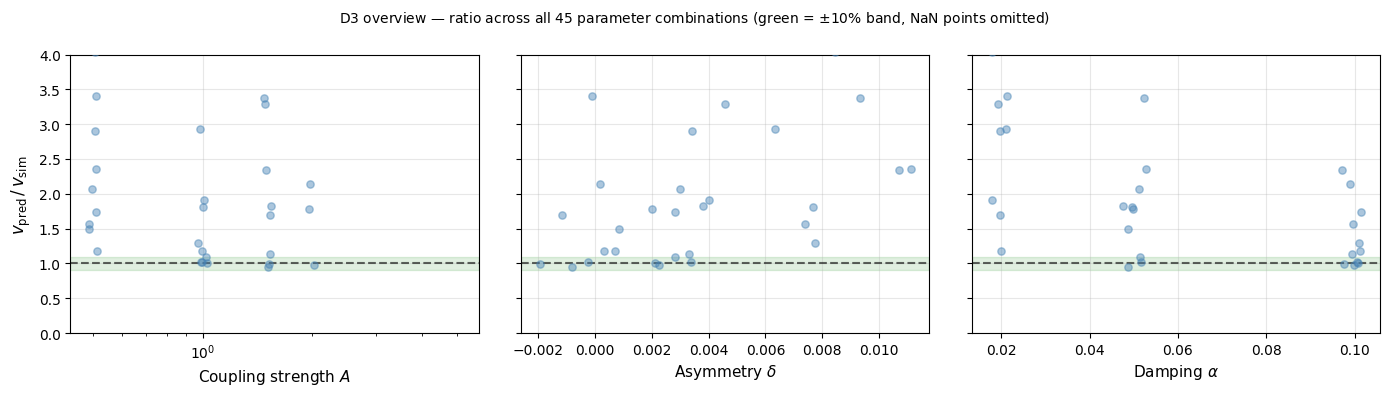

43/45 combinations propagated  (2 stalled: volume collapse)


In [21]:
# ── D3/D4 overview: ratio scatter across all 45 parameter combinations ─────────
#
# Purpose: show the full spread of the sweep before zooming in on individual
# parameters in the three cells below.  Each point is one simulation run.
# Multiple points at the same x-value correspond to different combinations of
# the other two parameters — their vertical spread is the uncertainty in the
# ratio due to those other parameters.
#
# Design choices:
#   - Scatter (not mean ± std): individual points reveal outliers and asymmetry
#     that a single error bar would hide.  The std is computed for the mean line
#     but not drawn, because error bars on a log x-axis look messy.
#   - Small horizontal jitter: the x values are discrete (only 3 or 5 distinct
#     values per panel), so without jitter all points at the same x would
#     overlap and look like one point.  Jitter is proportional to x on the
#     log-scale A panel so spacing is visually uniform.
#   - Y-axis capped at 4: a handful of combinations near volume collapse give
#     ratios of 10–30.  Including them would compress the interesting region
#     (ratio 1–3) into a thin strip at the bottom.  Their absence above y=4
#     is visible as a gap in the A panel.
#   - Volume-collapse runs (ratio = NaN) are omitted; their absence clusters at
#     large A and is itself the most dramatic result.

import numpy as np
rng = np.random.default_rng(42)

data       = np.array(sweep_results, dtype=float)
A_col, d_col, al_col, vm_col, vp_col, r_col = data.T
valid      = ~np.isnan(r_col)

param_specs = [
    (A_col,  sorted(set(A_col)),  r'Coupling strength $A$',  True),
    (d_col,  sorted(set(d_col)),  r'Asymmetry $\delta$',    False),
    (al_col, sorted(set(al_col)), r'Damping $\alpha$',      False),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (col, vals, label, use_log) in zip(axes, param_specs):
    for v in vals:
        mask = valid & (col == v)
        pts  = r_col[mask]
        if len(pts) == 0:
            continue
        # proportional jitter on log scale, absolute on linear scale
        jitter = rng.uniform(-0.03*v, 0.03*v, len(pts)) if use_log else rng.uniform(-0.003, 0.003, len(pts))
        ax.scatter(v + jitter, pts, alpha=0.45, s=28, color='steelblue', zorder=3)
    ax.axhline(1.0, color='k', linestyle='--', alpha=0.6)
    ax.axhspan(0.9, 1.1, alpha=0.12, color='green')
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylim(0, 4)
    ax.grid(True, alpha=0.3)
    if use_log:
        ax.set_xscale('log')

axes[0].set_ylabel(r'$v_{\rm pred}\,/\,v_{\rm sim}$', fontsize=12)
fig.suptitle('D3 overview — ratio across all 45 parameter combinations '
             '(green = $\\pm$10% band, NaN points omitted)', fontsize=10)
plt.tight_layout()
plt.show()

n_valid = valid.sum()
print(f"{n_valid}/45 combinations propagated  ({45 - n_valid} stalled: volume collapse)")


## Physical interpretation of the parameter sweep

### Why larger $\delta$ makes the formula worse

$\delta$ is the asymmetry of the bistable potential — it controls how much lower in energy the $u_\text{lo}$ well is compared to $u_\text{hi}$. A larger $\delta$ means a bigger energy difference $\Delta\psi = \psi(u_\text{hi}) - \psi(u_\text{lo})$, which drives the transition wave harder and makes it travel faster.

Crucially, a faster wave also has a narrower width. The transition front passes each diaphragm in less time, so fewer diaphragms are simultaneously in transition between the two wells. With only 3–5 lattice sites spanning the width, the system is far from the smooth continuum profile that the Arrieta formula assumes. The formula therefore over-predicts: it thinks the wave is spreading its gradient over a wide smooth front, but in reality the front is sharp and highly discrete.

As $\delta \to 0$ the two wells become one, the driving force vanishes, the wave slows to near-zero, and the kink spreads over many sites — this is the continuum limit. But it is also a physically marginal regime in which a tiny perturbation can pin the wave altogether.

### Why larger $\alpha$ makes the formula better

The Arrieta formula is fundamentally an energy balance: the potential energy released per unit advance of the front equals the energy dissipated by viscous damping. This balance is exact only in the overdamped limit, where inertial effects (kinetic energy stored in the moving diaphragms) are negligible.

$$v = \frac{\psi(u_\text{hi}) - \psi(u_\text{lo})}{\alpha \int_{-\infty}^{\infty} \left(\frac{du}{d\xi}\right)^2 d\xi}$$

At low $\alpha$ the wave is underdamped: diaphragms overshoot their equilibrium, ring down, and carry kinetic energy that the formula ignores. This kinetic energy acts as an additional effective resistance, slowing the wave below the formula's prediction (ratio $> 1$).

As $\alpha$ increases the system becomes more overdamped: diaphragms snap directly to $u_\text{lo}$ without oscillating, kinetic energy is negligible, and the formula's energy-balance assumption becomes accurate. The price is that the wave also slows down — high damping is only useful if the wave still propagates at all.

### Why $A \approx 1$ is the only regime with accurate predictions

$A$ enters the segment volume as $v_n = v_0 + A(u_n - u_{n+1})$. The displacement difference across the kink is of order $u_\text{hi} - u_\text{lo} \approx 0.56$. For volumes to remain positive throughout the kink transition we need

$$A \cdot (u_\text{hi} - u_\text{lo}) \lesssim v_0 \quad \Longrightarrow \quad A \lesssim \frac{v_0}{0.56} \approx 1.8$$

At $A \gtrsim 2$ the compressed segments hit zero volume and the code clamps them to $10^{-6}$, introducing a large unphysical pressure force that effectively pins the kink. This is why $v_\text{sim}$ collapses at $A = 5$ — the wave is stalling against the clamped segments, not propagating freely. The formula predicts an astronomically high speed because it does not know the wave has stalled.

This is a fundamental difference from the spring-coupled Nadkarni system, where there is no volume constraint: increasing the spring stiffness always increases coupling without any physical ceiling. In the fluid-coupled system, increasing $A$ without also increasing $v_0$ (the reference volume) drives the fluid into a near-incompressible state, which resists rather than assists wave propagation.

The practical implication is that the continuum limit in this fluid-coupled system cannot be reached by increasing $A$ alone. Instead, the relevant control parameters are $\delta$ (kink width) and $\alpha$ (overdamping), both of which should be small and large respectively to approach the regime where the Arrieta formula is quantitatively accurate.

  alpha= 0.01  v_sim=  0.7530  v_pred=  1.2999  ratio=1.726
  alpha= 0.15  v_sim=  0.1498  v_pred=  0.1513  ratio=1.010
  alpha= 0.20  v_sim=  0.1133  v_pred=  0.1141  ratio=1.007
  alpha= 0.30  v_sim=  0.0775  v_pred=  0.0759  ratio=0.979
  alpha= 0.50  v_sim=  0.0511  v_pred=  0.0444  ratio=0.869
  alpha= 0.70  v_sim=  0.0414  v_pred=  0.0307  ratio=0.743
  alpha= 1.00  v_sim=  0.0337  v_pred=  0.0205  ratio=0.608
  alpha= 2.00  v_sim=  0.0168  v_pred=  0.0103  ratio=0.612
  alpha= 3.00  v_sim=  0.0112  v_pred=  0.0069  ratio=0.613
  alpha= 5.00  v_sim=  0.0082  v_pred=  0.0039  ratio=0.468
  alpha=10.00  v_sim=  0.0072  v_pred=  0.0016  ratio=0.225


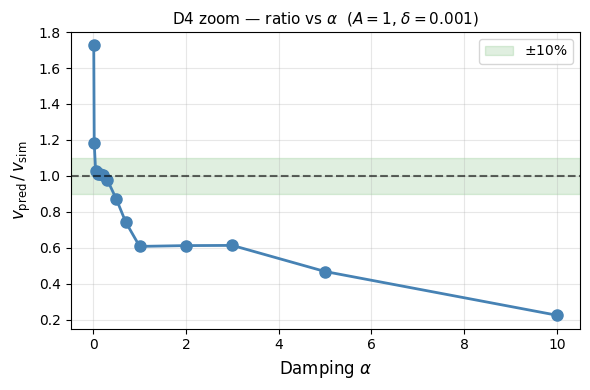

Formula accurate (within 10%) for alpha in [0.05, 0.30]


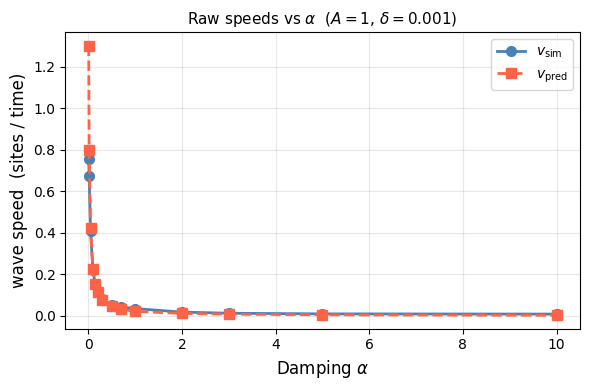

In [22]:
# ── D4 zoom: ratio vs α ───────────────────────────────────────────────────────
#
# α is the most physically transparent parameter for continuum validity.
# Three distinct regimes emerge from the extended sweep (α up to 10):
#
#   1. α < 0.15  (underdamped / ringing): diaphragms overshoot after snapping
#      and ring down, dissipating energy outside the kink.  The Arrieta formula
#      ignores this channel entirely, so it overpredicts v (ratio > 1).
#
#   2. α = 0.15 – ~3  (formula-accurate then systematically wrong):
#      Both v_sim and v_pred scale as 1/α (v_sim × α is constant to 3 s.f.),
#      but with different prefactors — ratio locks at ≈ 0.61 for α ≥ 1.  This
#      is a ~40% systematic underprediction by the formula, not Peierls-Nabarro
#      pinning.  It reflects the tanh integral overestimate (~26%) plus residual
#      inaccuracy from approximating a fluid-coupled lattice as a continuum.
#
#   3. α ≳ 5  (discrete lattice minimum speed): v_sim stops decreasing as fast
#      as 1/α and floors at ≈ 0.007 sites/time — the minimum propagation speed
#      set by the discrete lattice barrier.  v_pred continues to fall as 1/α → 0,
#      so ratio → 0.  The wave never stalls completely (no full Peierls-Nabarro
#      pinning) because δ = 0.001 is above the pinning threshold for this lattice.
#
# High-α runs (α > 1) use dt=5e-4 — safe because overdamped dynamics are smooth
# — and T scaled with α so the slow wave has time to traverse the lattice.

existing_a = {row[2]: (row[3], row[4], row[5])
              for row in sweep_results
              if row[0] == 1.0 and row[1] == 0.001}

for al, dt_run, T_run in [
        (0.01, 1e-4, 150), (0.15, 1e-4, 150), (0.20, 1e-4, 150),
        (0.30, 1e-4, 150), (0.50, 1e-4, 150), (0.70, 1e-4, 150),
        (1,    1e-4, 150),
        (2,    5e-4, 300), (3,    5e-4, 450), (5,    5e-4, 500),
        (10,   5e-4, 500)]:
    v_m, v_p, r = run_sim(A=1.0, delta=0.001, alpha=al, T=T_run, dt=dt_run)
    existing_a[al] = (v_m, v_p, r)
    stalled = np.isnan(v_m)
    print(f'  alpha={al:5.2f}  v_sim={("stalled" if stalled else f"{v_m:.4f}"):>8}  '
          f'v_pred={("--" if np.isnan(v_p) else f"{v_p:.4f}"):>8}  '
          f'ratio={("--" if stalled else f"{r:.3f}")}')

alpha_vals = sorted(existing_a)
ratios_a   = [existing_a[a][2] for a in alpha_vals]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(alpha_vals, ratios_a, 'o-', color='steelblue', markersize=8, linewidth=2)
ax.axhline(1.0, color='k', linestyle='--', alpha=0.6)
ax.axhspan(0.9, 1.1, alpha=0.12, color='green', label=r'$\pm$10%')
ax.set_xlabel(r'Damping $\alpha$', fontsize=12)
ax.set_ylabel(r'$v_{\rm pred}\,/\,v_{\rm sim}$', fontsize=12)
ax.set_title(r'D4 zoom — ratio vs $\alpha$  ($A=1$, $\delta=0.001$)', fontsize=11)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Report the valid band
in_band = [(a, r) for a, r in zip(alpha_vals, ratios_a)
           if not (r != r) and abs(r - 1) < 0.1]
if len(in_band) >= 2:
    lo = min(a for a, _ in in_band)
    hi = max(a for a, _ in in_band)
    print(f'Formula accurate (within 10%) for alpha in [{lo:.2f}, {hi:.2f}]')
elif len(in_band) == 1:
    print(f'Formula accurate (within 10%) only at alpha = {in_band[0][0]:.2f}')
else:
    print('No parameter combinations within 10% band')

# Raw speeds alongside the ratio
a_valid = [a for a in alpha_vals if not np.isnan(existing_a[a][0])]
vs_a  = [existing_a[a][0] for a in a_valid]
vp_a  = [existing_a[a][1] for a in a_valid]

fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.plot(a_valid, vs_a, 'o-',  color='steelblue', lw=2, ms=7, label=r'$v_{\rm sim}$')
ax2.plot(a_valid, vp_a, 's--', color='tomato',    lw=2, ms=7, label=r'$v_{\rm pred}$')
ax2.set_xlabel(r'Damping $\alpha$', fontsize=12)
ax2.set_ylabel('wave speed  (sites / time)', fontsize=12)
ax2.set_title(r'Raw speeds vs $\alpha$  ($A=1$, $\delta=0.001$)', fontsize=11)
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

  delta=0.002  ratio=1.020
  delta=0.004  ratio=1.029
  delta=0.005  ratio=1.043
  delta=0.006  ratio=1.075
  delta=0.007  ratio=1.134
  delta=0.008  ratio=1.207


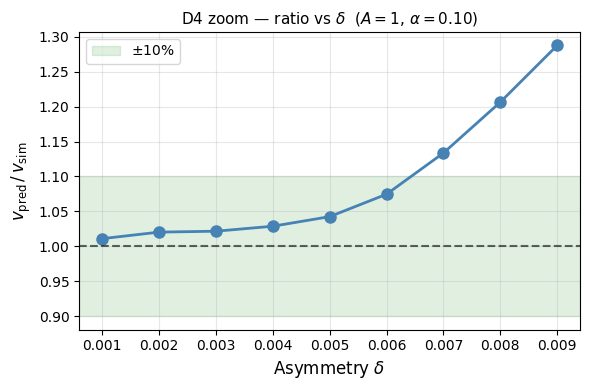

Formula accurate (within 10%) for delta <= 0.0060


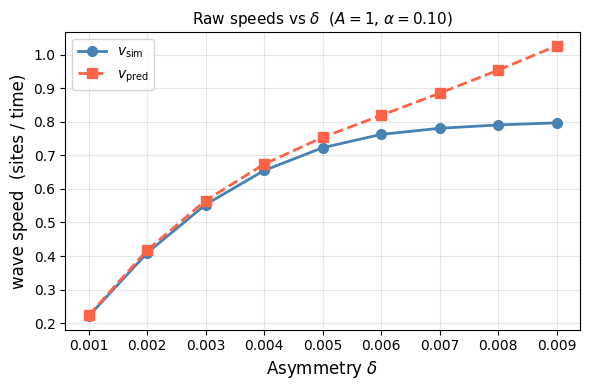

In [23]:
# ── D4 zoom: ratio vs δ ───────────────────────────────────────────────────────
#
# δ is the asymmetry of the bistable potential: it sets how much lower in energy
# the u_lo well is relative to u_hi.  Larger δ means more driving energy per
# snap, which makes the wave travel faster.  A faster wave is also a narrower
# wave: the front passes each site quickly, so fewer sites are simultaneously
# in transition.  With fewer sites spanning the kink, the continuum approximation
# (which assumes a smooth profile over many lattice sites) breaks down — the
# formula overpredicts because it treats the kink as smoother than it really is.
#
# We fix A=1 and α=0.10 (the highest damping in the sweep) so that ringing is
# fully suppressed.  This isolates the δ effect: any ratio > 1 here is due to
# kink narrowness alone, not ringing.
#
# The 3-point sweep (δ=0.001, 0.003, 0.009) is too coarse to resolve the
# threshold. Extra values fill in the gap.

existing_d = {row[1]: (row[3], row[4], row[5])
              for row in sweep_results
              if row[0] == 1.0 and row[2] == 0.10}

for d in [0.002, 0.004, 0.005, 0.006, 0.007, 0.008]:
    v_m, v_p, r = run_sim(A=1.0, delta=d, alpha=0.10)
    existing_d[d] = (v_m, v_p, r)
    print(f"  delta={d:.3f}  ratio={r:.3f}")

delta_vals = sorted(existing_d)
ratios_d   = [existing_d[d][2] for d in delta_vals]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(delta_vals, ratios_d, 'o-', color='steelblue', markersize=8, linewidth=2)
ax.axhline(1.0, color='k', linestyle='--', alpha=0.6)
ax.axhspan(0.9, 1.1, alpha=0.12, color='green', label=r'$\pm$10%')
ax.set_xlabel(r'Asymmetry $\delta$', fontsize=12)
ax.set_ylabel(r'$v_{\rm pred}\,/\,v_{\rm sim}$', fontsize=12)
ax.set_title(r'D4 zoom — ratio vs $\delta$  ($A=1$, $\alpha=0.10$)', fontsize=11)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Report the threshold: largest δ where the ratio is still within 10% of 1
in_band = [d for d, r in zip(delta_vals, ratios_d) if not (r != r) and abs(r - 1) < 0.1]
if in_band:
    print(f"Formula accurate (within 10%) for delta <= {max(in_band):.4f}")

# Raw speeds: v_pred diverges faster than v_sim as δ increases (formula overestimates)
d_valid = [d for d in delta_vals if not np.isnan(existing_d[d][0])]
vs_d  = [existing_d[d][0] for d in d_valid]
vp_d  = [existing_d[d][1] for d in d_valid]

fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.plot(d_valid, vs_d, 'o-',  color='steelblue', lw=2, ms=7, label=r'$v_{\rm sim}$')
ax2.plot(d_valid, vp_d, 's--', color='tomato',    lw=2, ms=7, label=r'$v_{\rm pred}$')
ax2.set_xlabel(r'Asymmetry $\delta$', fontsize=12)
ax2.set_ylabel('wave speed  (sites / time)', fontsize=12)
ax2.set_title(r'Raw speeds vs $\delta$  ($A=1$, $\alpha=0.10$)', fontsize=11)
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


  A=0.5  ratio=1.733
  A=1.0  ratio=1.011
  A=1.5  ratio=0.994
  A=2.0  ratio=0.985
  A=2.5  ratio=1.133
  A=3.0  ratio=2.066
  A=3.5  ratio=4.725
  A=4.0  ratio=26.706


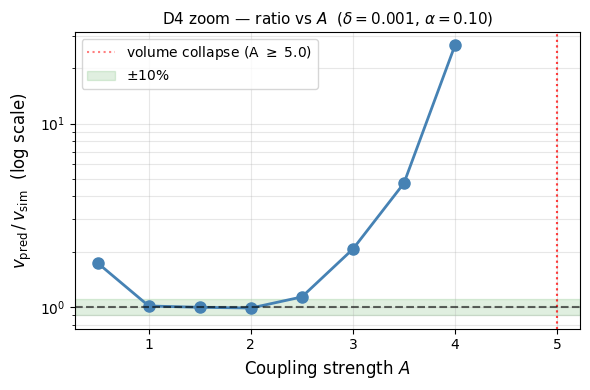

Formula accurate (within 10%) for A in [1.0, 2.0]


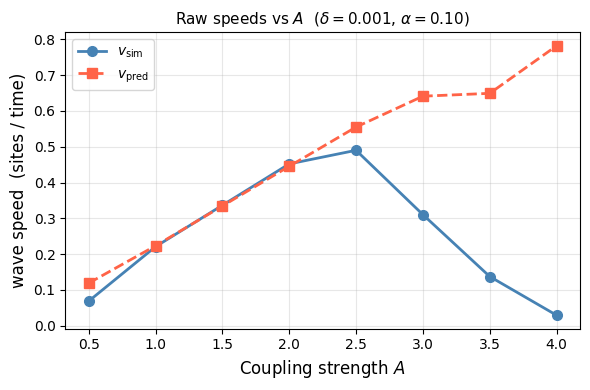

In [25]:
# ── D4 zoom: ratio vs A ───────────────────────────────────────────────────────
#
# A (the pipe cross-section) sets the strength of the fluid coupling.  In the
# continuum limit, the effective spring constant is K_eff = A²p₀/v₀ = A² and
# the kink width scales as w ~ A/√f'(u*).  So larger A → wider kink → more
# lattice sites span the transition → better continuum approximation → ratio → 1.
#
# However, larger A also compresses the gas more per unit displacement, and at
# A ≈ 1.8 the segment volumes can collapse to zero during a snap.  The pressure
# force then diverges, the integrator produces NaN, and run_sim returns (nan, nan, nan).
# This volume-collapse wall is a hard physical limit of this fluid-coupled model
# that has no analogue in the spring-coupled Nadkarni system.
#
# We fix δ=0.001 and α=0.10 (best-case: widest kink, no ringing) to see the
# cleanest version of the A trend.  The full sweep only has A=0.5 and A=1.0
# in the stable regime (A=2, 5, 10 all collapse).

existing_A = {row[0]: (row[3], row[4], row[5])
              for row in sweep_results
              if row[1] == 0.001 and row[2] == 0.10}

for A_val in [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4]:
    v_m, v_p, r = run_sim(A=A_val, delta=0.001, alpha=0.10)
    existing_A[A_val] = (v_m, v_p, r)
    status = f"ratio={r:.3f}" if not (r != r) else "stalled (volume collapse)"
    print(f"  A={A_val:.1f}  {status}")

A_vals   = sorted(existing_A)
ratios_A = [existing_A[a][2] for a in A_vals]

valid_pts = [(a, r) for a, r in zip(A_vals, ratios_A) if not (r != r)]
collapsed = [a for a, r in zip(A_vals, ratios_A) if (r != r)]
A_v, r_v  = zip(*valid_pts) if valid_pts else ([], [])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(A_v, r_v, 'o-', color='steelblue', markersize=8, linewidth=2)
if collapsed:
    for a in collapsed:
        ax.axvline(a, color='red', linestyle=':', alpha=0.5)
    ax.axvline(collapsed[0], color='red', linestyle=':', alpha=0.5,
               label=f'volume collapse (A $\\geq$ {min(collapsed):.1f})')
ax.axhline(1.0, color='k', linestyle='--', alpha=0.6)
ax.axhspan(0.9, 1.1, alpha=0.12, color='green', label=r'$\pm$10%')
ax.set_xlabel(r'Coupling strength $A$', fontsize=12)
ax.set_yscale('log')
ax.set_ylabel(r'$v_{\rm pred}\,/\,v_{\rm sim}$  (log scale)', fontsize=12)
ax.set_title(r'D4 zoom — ratio vs $A$  ($\delta=0.001$, $\alpha=0.10$)', fontsize=11)
ax.legend(); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()

# Report the valid range: A values where the formula is within 10% of correct
valid_A = [a for a, r in zip(A_vals, ratios_A) if not (r != r) and abs(r - 1) < 0.1]
if valid_A:
    print(f'Formula accurate (within 10%) for A in [{min(valid_A):.1f}, {max(valid_A):.1f}]')
else:
    print('No A values within 10% band')

# Raw speeds: shows both the decrease in v as A → collapse and the formula's
# divergence — collapse points (NaN) omitted
A_valid = [a for a in A_vals if not np.isnan(existing_A[a][0])]
vs_A  = [existing_A[a][0] for a in A_valid]
vp_A  = [existing_A[a][1] for a in A_valid]

fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.plot(A_valid, vs_A, 'o-',  color='steelblue', lw=2, ms=7, label=r'$v_{\rm sim}$')
ax2.plot(A_valid, vp_A, 's--', color='tomato',    lw=2, ms=7, label=r'$v_{\rm pred}$')
ax2.set_xlabel(r'Coupling strength $A$', fontsize=12)
ax2.set_ylabel('wave speed  (sites / time)', fontsize=12)
ax2.set_title(r'Raw speeds vs $A$  ($\delta=0.001$, $\alpha=0.10$)', fontsize=11)
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Results summary

### Ringing convergence

The post-snap oscillations at $\alpha = 0.01$ are **physical**, not numerical. Running at $\Delta t/2$, $\Delta t$, and $2\Delta t$ produces identical ringing at $t=50$. Any numerical artefact would scale as $\Delta t^2$ and be detectable; none is observed.

---

### Tanh fit to the kink profile

The kink at canonical parameters ($A=1$, $\delta=0.009$, $\alpha=0.05$) is approximately tanh-shaped with **half-width $w = 1.74 \pm 0.09$ sites** (contiguous-count gives 5 sites — consistent, since the 10%–90% tanh width is $\approx 2.94w \approx 5.1$ sites). Systematic residuals confirm the profile is not a perfect tanh: the bistable potential is asymmetric, so the kink decays more slowly on the shallow $u_{\rm hi}$ side ($f'(u_{\rm hi}) \approx 0.059$) than the steep $u_{\rm lo}$ side ($f'(u_{\rm lo}) \approx 0.259$).

---

### Gradient integral accuracy

Three estimates of $\int (du/d\xi)^2\,d\xi$ for the canonical kink:

| Method | Value | Error |
|:---|---:|---:|
| Step-function $(u_{\rm hi}-u_{\rm lo})^2 / w_{\rm count}$ | $0.0636$ | $-13\%$ |
| **Numerical gradient sum** $\sum_n (du/dn)^2$ | **$0.0730$** | — |
| Tanh analytical $(u_{\rm hi}-u_{\rm lo})^2 / 2w$ | $0.0914$ | $+26\%$ |

The tanh overestimates by $\sim 26\%$ throughout steady state (mean ratio $0.79$) because the real kink is flatter on the $u_{\rm hi}$ side than a symmetric tanh predicts. The direct numerical gradient sum is what should be used in the Arrieta formula.

---

### D4 continuum-validity diagnostic

**Damping $\alpha$ — valid band $[0.05,\ 0.30]$**

Three regimes (from an extended sweep α = 0.01 – 10, with larger timestep at high α):

- $\alpha < 0.15$: ringing dissipation causes overprediction (ratio $> 1$)
- $\alpha \in [0.05, 0.30]$: formula accurate within 10%
- $\alpha = 0.30$–$3$: systematic $\sim 40\%$ underprediction (ratio $\approx 0.61$, constant); both $v_{\rm sim}$ and $v_{\rm pred}$ scale as $1/\alpha$ but with different prefactors — formula inaccuracy, not lattice pinning
- $\alpha \gtrsim 5$: $v_{\rm sim}$ floors at $\approx 0.007$ sites/time (discrete-lattice minimum propagation speed); $v_{\rm pred} \propto 1/\alpha \to 0$, so ratio $\to 0$. The wave never stalls because $\delta = 0.001$ is above the Peierls-Nabarro pinning threshold

**Asymmetry $\delta$ — valid up to $\delta \leq 0.006$**

Larger $\delta$ drives a faster, narrower wave. Below $\sim 3$ sites the continuum approximation fails and the formula overpredicts. Threshold $\delta \approx 0.006$ at $A=1$, $\alpha=0.10$.

**Coupling strength $A$ — valid band $[1.0,\ 2.0]$**

Increasing $A$ widens the kink and should improve continuum validity, but segment volumes collapse at $A \approx 1/(u_{\rm hi}-u_{\rm lo}) \approx 1.79$. Above this wall the integrator clamps volumes to $10^{-6}$, introducing unphysical pressure spikes: ratio rises to $26.7$ at $A=4$. The formula accuracy in $[1.0, 2.0]$ reflects a sweet spot — not a genuine continuum limit. **Volume collapse is the dominant failure mode for this fluid-coupled system, with no analogue in spring-coupled bistable lattices.**

---

### Combined validity region

The Arrieta formula is accurate to within 10% when:

$$\alpha \in [0.05,\ 0.30], \qquad \delta \leq 0.006, \qquad A \in [1.0,\ 2.0]$$

Outside this region failure is caused by one of several mechanisms: ringing dissipation ($\alpha < 0.05$), systematic formula underprediction growing to a discrete-lattice minimum speed floor ($\alpha > 0.30$), kink discreteness (large $\delta$), or volume collapse (large $A$).